# DES Y3 cosmic shear: data vectors from the compiled CosmoLike interface

This notebook computes the cosmic-shear predictions of the DES Y3 project with
`cosmolike_des_y3_interface`, the project's *compiled interface*: C and C++ code
built into a Python module (through the pybind11 library), imported below as
`ci`. It shows

- the shear angular power spectra $C_\ell^{EE}$ and the real-space correlation
  functions $\xi_\pm(\theta)$ of the four source-galaxy redshift bins;
- how $\Omega_m$, $n_s$, the angular binning, baryonic feedback and the numerical
  accuracy settings change them;
- the $\chi^2=(d-t)^{\mathsf T}C^{-1}(d-t)$ of the model against the DES Y3
  measurements, with $d$ the measured data vector, $t$ the prediction and $C$
  the published DES Y3 covariance matrix (the joint scatter of the measurements).

**Vocabulary.**

- A *tomographic bin* is one redshift slice of a galaxy sample. DES Y3 has four
  *source* bins, galaxies whose shapes measure the gravitational shear, and five
  redMaGiC *lens* bins, galaxies used as density tracers (they appear in
  EXAMPLE_EVALUATE2.ipynb). Redshifts come from broad-band colors (*photo-z*).
- The multipole $\ell$ is an angular frequency, roughly $180^\circ/\theta$;
  $C_\ell$ is the angular power spectrum at that frequency.
- The *data vector* is the ordered list of all measured two-point values. The
  DES Y3 3×2pt vector has 900 entries: 20 angular bins for each of the 10
  source-bin pairs of $\xi_+$ and of $\xi_-$, then galaxy–galaxy lensing and
  clustering. Its baseline *mask*, one 0/1 flag per entry, keeps 533 entries,
  227 of them $\xi_\pm$ entries.
- A *wrapper* is a Python function of this notebook that runs CAMB, hands the
  result and the nuisance parameters to `ci`, and returns NumPy arrays.

**Conventions.**

- Angles $\theta$ are in arcminutes throughout.
- `ci` returns plain, dimensionless $C_\ell$, without the factor
  $\ell(\ell+1)/2\pi$. The shear-spectrum plotter multiplies by that factor in
  its absolute panels; the $\xi$ plotter draws $\theta\,\xi_\pm\times10^4$.
- Arrays count tomographic bins from 0, panel labels count from 1: the panel
  labeled $(1,2)$ draws the array slice `[:, 0, 1]`.

**Running.** Follow the [notebook steps of the project README](README.md#notebooks)
(activate Cocoa, set `OMP_NUM_THREADS`, start Jupyter) and run the cells in
order. Every wrapper call runs CAMB once, so a sweep of ten values costs ten
CAMB runs.

## Setup: packages, threads and figure style

The first cell imports the packages and sets the figure style; the second adds
CAMB and the shared package `cosmolike_notebook_utils` (imported as `cnu`) to
`sys.path`, the list of folders Python searches for modules, and prints which
copies were found.

- `OMP_NUM_THREADS` sets how many OpenMP threads (parallel workers inside the
  compiled code) CosmoLike uses. An OpenMP runtime reads it once, when it
  starts, so the README sets it in the shell before Jupyter starts; the cell
  sets it again before `ci` is imported.
- `text.usetex = True` typesets all figure text with LaTeX and needs a LaTeX
  installation; set it to `False` if the figures fail to render.
- `IniFile` (from GetDist) reads `key = value` text files such as the project's
  `.dataset` file.

In [1]:
# Figures appear below each cell; 'retina' draws them at double resolution.
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
# OpenMP threads (parallel workers) of the compiled CosmoLike loops. The
# OpenMP runtime reads this variable once, when it starts, so it is set
# before ci is imported; the README sets it in the shell before Jupyter.
os.environ['OMP_NUM_THREADS'] = '12'
import matplotlib
import math
from matplotlib import pyplot as plt
import numpy as np
# EuclidEmulator2: used only when non_linear_emul = 1
import euclidemu2
import scipy
# ci: the project's compiled CosmoLike module
import cosmolike_des_y3_interface as ci
# IniFile reads key = value text files such as the .dataset file
from getdist import IniFile
import itertools
import iminuit
import functools
print(sys.version)
print(os.getcwd())

# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'
# usetex typesets all figure text with LaTeX: it needs a LaTeX installation
matplotlib.rcParams['text.usetex'] = True

# Jupyter Notebook Display options
import IPython
IPython.display.display(IPython.display.HTML("<style>:root { --jp-notebook-max-width: 85% !important; }</style>"))
IPython.display.display(IPython.display.HTML("<style>div.output_scroll { height: 54em; }</style>"))


Classy could not be found in your system.
Here are some suggestions:

	 -Download the Class from class-code.net and install it
	  together with its wrapper classy (type 'make' instead of
	  'make class'
	 -If you know that Class is installed on your system
	  and yet classy could not be installed, try re-compiling
	  Class with just ''make'' instead of ''make class''
NOTICE: Even without classy you can still use EuclidEmulator2
        to emulate boost factors. You won't be able to compute
        full power spectra, though.


3.11.12 | packaged by conda-forge | (main, Apr 10 2025, 22:18:52) [Clang 18.1.8 ]
/Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/des_y3


In [2]:
# IMPORT CAMB
# This build folder exists only on Linux x86_64. Python skips a missing
# folder in sys.path, so camb may come from another entry; the print shows
# which copy was imported.
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/CAMB/build/lib.linux-x86_64-'+os.environ['PYTHON_VERSION'])
import camb
from camb import model
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

# IMPORT SHARED NOTEBOOK UTILITIES (cosmolike_core)
# cnu: the CAMB helper and plotting functions shared by every project
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/cosmolike_core')
import cosmolike_notebook_utils as cnu
print('Using cosmolike_notebook_utils installed at %s'%(os.path.dirname(cnu.__file__)))


Using CAMB 1.6.7 installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/.local/lib/python3.11/site-packages/camb
Using cosmolike_notebook_utils installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/external_modules/code/cosmolike_core/cosmolike_notebook_utils


## Run settings

These module-level variables (names defined at the top level of the notebook)
mirror keys of the likelihood YAML files, `likelihood/cosmic_shear.yaml` and
`EXAMPLE_EVALUATE1.yaml`:

| Variable | Meaning |
| --- | --- |
| `non_linear_emul` | Nonlinear matter power: 1 = EuclidEmulator2, 2 = CAMB Halofit (Takahashi version). |
| `CLprobe` | Probe combination of the $\chi^2$ section; `"xi"` is cosmic shear alone. |
| `path`, `data_file` | The DES Y3 dataset file; `path` is relative to this notebook's folder. |
| `IA_model` | Intrinsic-alignment model: 0 = NLA, 1 = TATT. |
| `IA_redshift_evolution` | 3 = each IA amplitude follows a power law in $(1+z)/1.62$. |
| `IA_code` | 0 = the C implementation of FAST-PT, the algorithm for the perturbation-theory integrals of TATT. |
| `photoz_interpolation_type`, `photoz_zmid_convention` | How the $n(z)$ tables are interpolated, and whether their redshift column holds left bin edges or bin centers. |
| `internal_accuracyboost` | FAST-PT internal grid, as a fraction of its output table. |
| `ntheta`, `theta_min_arcmin`, `theta_max_arcmin` | 20 logarithmic angular bins from 2.5 to 250 arcmin, as in the dataset. |

*Intrinsic alignment* (IA) is the correlation of galaxy shapes with the local
tidal field; it adds to the lensing signal and must be modeled. NLA, the
nonlinear linear-alignment model, has one amplitude $A_1$; TATT (tidal alignment
and tidal torquing) adds a quadratic amplitude $A_2$ and $b_{TA}$, which weights
the alignment by the source-galaxy density.

`CAMBAccuracyBoost` is not read by the wrappers below; each wrapper has its own
`CAMBAccuracyBoost = 1.1` default argument.

In [3]:
# Not read by the wrappers below: each has its own CAMBAccuracyBoost default
CAMBAccuracyBoost = 1.1
# Nonlinear power: 1 = EuclidEmulator2, 2 = CAMB Halofit (Takahashi)
non_linear_emul = 2
# Probe combination of the chi^2 section: xi = cosmic shear alone
CLprobe="xi"

# Relative to this notebook's folder; start_cocoa.sh links
# external_modules/data/des_y3 to this project's data folder.
path= "../../external_modules/data/des_y3"
data_file="des_y3_real.dataset"

# IA_model: 0 = NLA, 1 = TATT. IA_redshift_evolution = 3: power law in
# (1+z)/1.62, so A1 = [amplitude, exponent, ...] and likewise A2.
IA_model = 1
IA_redshift_evolution = 3
IA_code = 0  # 0 = C FASTPT, 1 = Python FAST-PT (NLA always uses 0)

# n(z) photo-z conventions (mirror the likelihood yaml keys):
# interpolation 0 = cspline, 1 = linear, 2+ = Steffen monotone;
# z column 0 = Z_LOW (left bin edges), 1 = Z_MID (sample points)
photoz_interpolation_type = 0
photoz_zmid_convention = 0

# C FAST-PT grid of the TATT and nonlinear-bias tables, as a fraction
# of its output table (mirrors the likelihood yaml key
# internal_accuracyboost, 1.0 in likelihood/*.yaml; the C default,
# used when nothing sets it, is 0.5)
internal_accuracyboost = 1.0

# 20 logarithmic angular bins from 2.5 to 250 arcmin, as in the dataset
ntheta = 20 
theta_min_arcmin = 2.5 
theta_max_arcmin = 250 

## Fiducial parameters

The default values of the wrapper arguments:

- Cosmology: `As_1e9` $=10^9A_s$, the primordial amplitude; `ns` $=n_s$; `H0` in
  km/s/Mpc; `omegab` $=\Omega_b$; `omegam` $=\Omega_m$, all matter including
  massive neutrinos; `mnu` $=\sum m_\nu$ in eV; `w` $=w_0$ and `w0pwa` $=w_0+w_a$,
  so $w_a=0$ here.
- Source photo-z shifts `DES_DZ_S1..4`: each source $n(z)$ is shifted in
  redshift by $\Delta z_i$.
- Shear calibration `DES_M1..4`: the measured shear of bin $i$ is $1+m_i$ times
  the true shear.
- TATT with power-law evolution: `DES_A1_1`, `DES_A1_2` are $A_1$ at $1+z=1.62$
  and its exponent $\eta_1$; `DES_A2_1`, `DES_A2_2` the same pair for $A_2$;
  `DES_BTA_1` is $b_{TA}$.

These are the values of the `sampler: evaluate: override` block of
`EXAMPLE_EVALUATE1.yaml`, except `DES_A2_1`, which that file sets to 0.01.

In [4]:
# Cosmology: As_1e9 = 10^9 A_s, H0 in km/s/Mpc, mnu = sum of neutrino
# masses in eV; w0pwa = w0 + wa (below), so wa = w0pwa - w = 0.
As_1e9 = 2.1
ns = 0.96605
H0 = 67.32
omegab = 0.04
omegam = 0.3
mnu = 0.06
# Source bins 1-4: photo-z shifts Delta z_i and shear calibration m_i
DES_DZ_S1 = 0.0414632
DES_DZ_S2 = 0.00147332
DES_DZ_S3 = 0.0237035
DES_DZ_S4 = -0.0773436
DES_M1 = 0.0191832
DES_M2 = -0.0431752
DES_M3 = -0.034961
DES_M4 = -0.0158096
# TATT: (A1, eta1) = (DES_A1_1, DES_A1_2), (A2, eta2) = (DES_A2_1,
# DES_A2_2), b_TA = DES_BTA_1. EXAMPLE_EVALUATE1.yaml sets DES_A2_1 = 0.01.
DES_A1_1 = 0.606102
DES_A1_2 = -1.51541
DES_A2_1 = -1.7938938475734911 
DES_A2_2 = -1.5448080290038528
DES_BTA_1 = 0.8154011496506723
w0pwa = -0.9
w = -0.9

## Stage 1, CAMB: matter power spectrum, growth and distances

Each wrapper starts with one CAMB run through `cnu.get_camb_cosmology`, shared by
every Cocoa project; `help(cnu.get_camb_cosmology)` prints its documentation.
It returns the ten arrays that `ci.set_cosmology` reads, in CosmoLike's units:

| Returned names | Content |
| --- | --- |
| `log10k_interp_2D`, `z_interp_2D` | The grids of $\log_{10}k$, with $k$ in $h$/Mpc, and of redshift of the power-spectrum tables. |
| `lnPL`, `lnPNL` | $\ln P(k,z)$, linear and nonlinear, with $P$ in (Mpc/$h$)$^3$, each table flattened into one array. |
| `G_growth`, `z_growth` | $G(z)=D(z)(1+z)$, with $D$ the linear growth factor, normalized at the last redshift of the 2D grid, on its own redshift grid. |
| `z_interp_1D`, `chi` | The comoving distance $\chi(z)$ in Mpc/$h$. |
| `omegan2`, `lnPL_cb` | $\Omega_\nu h^2$ and the linear power of cold dark matter plus baryons, read by halo-model quantities; the wrappers pass `omegan2` only. |

*Flattened* means the 2D table $(z,k)$ is stored as one 1D array, column after
column (Fortran order), the memory layout the compiled code expects.

Two knobs reach CAMB: it runs with accuracy
`CAMBAccuracyBoost`$\times(1+(\texttt{AccuracyBoost}-1)/3)$, and the redshift and
wavenumber grids grow with `CLAccuracyBoost`$\times$`AccuracyBoost`.

In [5]:
# get_camb_cosmology is shared by every project's notebooks; call it as
# cnu.get_camb_cosmology (imported above). The CAMB side runs with
# CAMBAccuracyBoost*(1 + (AccuracyBoost - 1)/3); kmax, k_per_logint, the
# chi(z) node count and lens_potential_accuracy grow with that CAMB boost;
# the EuclidEmulator2 boost (non_linear_emul = 1) applies only at z < 10.
# help(cnu.get_camb_cosmology) prints the full documentation.


## Stages 2 to 5: the harmonic-space wrapper `C_ss_tomo_limber`

After CAMB, each call runs four more stages:

2. **Accuracy of the C code.** `init_ntable_lmax` sets the largest multipole of
   the spectra tabulated for real-space transforms (50,000 at boost 1);
   `init_accuracy_boost` sets the size of CosmoLike's interpolation tables and
   the *quadrature level*, which picks how many points evaluate each
   line-of-sight integral; `init_photoz_conventions` sets how the $n(z)$ tables
   are read. The level passed is
   `CLIntegrationAccuracy` $+\,|3(\text{boost}-1)|$, rounded down, with
   boost $=$ `CLAccuracyBoost`$\times$`AccuracyBoost`: any boost different from
   1, above or below, raises it.
3. **`ci.set_cosmology`** copies the CAMB tables into CosmoLike, which reads them
   in every later calculation.
4. **Nuisance setters.** `set_nuisance_shear_calib` receives the four $m_i$,
   `set_nuisance_shear_photoz` the four $\Delta z_i$ and `set_nuisance_ia` the IA
   lists. With `IA_redshift_evolution = 3` only the first two entries of `A1` and
   of `A2` (amplitude, exponent) and the first entry of `B_TA` are read; the
   trailing zeros make each list as long as the number of source bins, which the
   setter requires. `reset_bary_struct` switches baryonic feedback off;
   `init_baryons_contamination` switches it on (see the baryon section).
5. **The data-vector call** `ci.C_ss_tomo_limber(l=ell)` returns a pair
   `(EE, BB)` of arrays with shape `[n_ell, n_source, n_source]`. Only the
   entries `[:, i, j]` with $i\le j$ are filled; the others are zero. The values
   are plain, dimensionless $C_\ell$ in the *Limber approximation*, which
   evaluates the matter power at $k=(\ell+1/2)/\chi$ along the line of sight
   instead of integrating over all wavenumbers; it loses accuracy only at the
   lowest multipoles.

The E mode is the curl-free pattern of the shear field, the pattern lensing
produces; in this model a B mode (curl pattern) comes only from the TATT terms.

**Python detail.** The default values in the `def` line (`omegam = omegam`, ...)
are copied once, when the cell runs: rerun the cell after editing the fiducial
values. Names that are not arguments (`mnu`, `non_linear_emul`, the photo-z
conventions and `ini`) are read from the notebook at every call; `ini` is created
by the initialization cell further below, which must run before the first call.

In [6]:
def C_ss_tomo_limber(ell, 
                     omegam = omegam, 
                     omegab = omegab, 
                     H0 = H0, 
                     ns = ns, 
                     As_1e9 = As_1e9, 
                     w = w, 
                     w0pwa = w0pwa,
                     A1  = [DES_A1_1, DES_A1_2, 0, 0], 
                     A2  = [DES_A2_1, DES_A2_2, 0, 0],
                     BTA = [DES_BTA_1, 0, 0, 0],
                     shear_photoz_bias = [DES_DZ_S1, DES_DZ_S2, DES_DZ_S3, DES_DZ_S4],
                     M = [DES_M1, DES_M2, DES_M3, DES_M4],
                     baryon_sims = None,
                     AccuracyBoost = 1.0, 
                     kmax = 10, 
                     k_per_logint = 20, 
                     CAMBAccuracyBoost=1.1,
                     CLAccuracyBoost = 1.0, 
                     CLIntegrationAccuracy = 1):

    # Stage 1, CAMB: the ten arrays of the CAMB section (lnPL_cb is not used)
    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_growth, z_interp_1D, chi,
     omegan2, lnPL_cb) = cnu.get_camb_cosmology(omegam=omegam, 
        omegab=omegab, H0=H0, ns=ns, As_1e9=As_1e9, w=w, w0pwa=w0pwa, mnu=mnu, non_linear_emul=non_linear_emul,
            AccuracyBoost=AccuracyBoost, kmax=kmax,
        k_per_logint=k_per_logint, CAMBAccuracyBoost=CAMBAccuracyBoost,
        CLAccuracyBoost=CLAccuracyBoost)

    # Stage 2, accuracy of the C code. The quadrature level grows by 3 per
    # unit of |boost - 1|, so a boost below 1 raises it too.
    CLAccuracyBoost = CLAccuracyBoost * AccuracyBoost
    CLIntegrationAccuracy = max(0, CLIntegrationAccuracy + abs(3*(CLAccuracyBoost-1.0)))
    ci.init_ntable_lmax(int(50000 + 20000*(CLAccuracyBoost-1)))
    ci.init_accuracy_boost(CLAccuracyBoost, int(CLIntegrationAccuracy))
    ci.init_photoz_conventions(
        int(photoz_interpolation_type),
        int(photoz_zmid_convention))

    # Stage 3: copy the CAMB tables into CosmoLike
    ci.set_cosmology(omegam = omegam, 
                     H0 = H0, 
                     log10k_2D = log10k_interp_2D, 
                     z_2D = z_interp_2D, 
                     lnP_linear = lnPL,
                     lnP_nonlinear = lnPNL,
                     G = G_growth,
                     z_G = z_growth,
                     z_1D = z_interp_1D,
                     chi = chi,
                     omegan2 = omegan2)
    # Stage 4, nuisance parameters. With IA_redshift_evolution = 3 the IA
    # setter reads A1[0:2], A2[0:2] and BTA[0]; the zeros pad each list to
    # the number of source bins, which the setter requires.
    ci.set_nuisance_shear_calib(M = M)
    ci.set_nuisance_shear_photoz(bias = shear_photoz_bias)
    ci.set_nuisance_ia(A1 = A1, A2 = A2, B_TA = BTA)

    # Baryonic feedback off (dark-matter-only power), or the tabulated power
    # ratio of the named simulation; ini comes from the initialization cell.
    if baryon_sims is None:
        ci.reset_bary_struct()
    else:
        ci.init_baryons_contamination(sim = baryon_sims,
            allsims = ini.relativeFileName('all_sims_hdf5_file'))
        
    # Stage 5: the pair (EE, BB), each [n_ell, n_source, n_source] with only
    # [:, i, j], i <= j, filled: plain dimensionless Limber C_ell
    return ci.C_ss_tomo_limber(l = ell)

## The real-space wrapper `xi`

`xi(...)` runs the same stages and adds `ci.init_binning(ntheta, theta_min,
theta_max)`, which defines `ntheta` logarithmic angular bins between the two
angles in arcmin. `ci.xi_pm_tomo()` transforms the tabulated $C_\ell$, up to the
`init_ntable_lmax` multipole, into $\xi_+$ and $\xi_-$ averaged over each angular
bin rather than evaluated at its center.

The wrapper returns the tuple `(theta, xi_plus, xi_minus)`: `theta` holds the
area-weighted centers of the angular bins in arcmin
(`ci.get_binning_real_space()`), and each $\xi$ array has the shape
`[n_theta, n_source, n_source]`, symmetric in the two bin indices. This tuple is
the input format of `cnu.plot_xi`.

In [7]:
def xi(ntheta = ntheta, 
       theta_min_arcmin = theta_min_arcmin, 
       theta_max_arcmin = theta_max_arcmin, 
       omegam = omegam, 
       omegab = omegab, 
       H0 = H0, 
       ns = ns, 
       As_1e9 = As_1e9, 
       w = w, 
       w0pwa = w0pwa,
       A1  = [DES_A1_1, DES_A1_2, 0.0, 0.0], 
       A2  = [DES_A2_1, DES_A2_2, 0.0, 0.0],
       BTA = [DES_BTA_1, 0, 0, 0.0, 0.0],     
       shear_photoz_bias = [DES_DZ_S1, DES_DZ_S2, DES_DZ_S3, DES_DZ_S4],
       M = [DES_M1, DES_M2, DES_M3, DES_M4],
       baryon_sims = None,
       AccuracyBoost = 1.0, 
       kmax = 10, 
       k_per_logint = 20, 
       CAMBAccuracyBoost=1.1,
       CLAccuracyBoost = 1.0, 
       CLIntegrationAccuracy = 1):

    # Stage 1, CAMB
    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_growth, z_interp_1D, chi,
     omegan2, lnPL_cb) = cnu.get_camb_cosmology(omegam=omegam, 
        omegab=omegab, H0=H0, ns=ns, As_1e9=As_1e9, w=w, w0pwa=w0pwa, mnu=mnu, non_linear_emul=non_linear_emul,
            AccuracyBoost=AccuracyBoost, kmax=kmax,
        k_per_logint=k_per_logint, CAMBAccuracyBoost=CAMBAccuracyBoost,
        CLAccuracyBoost=CLAccuracyBoost)

    # Stage 2, accuracy of the C code, as in C_ss_tomo_limber
    CLAccuracyBoost = CLAccuracyBoost * AccuracyBoost
    CLIntegrationAccuracy = max(0, CLIntegrationAccuracy + abs(3*(CLAccuracyBoost-1.0)))
    ci.init_ntable_lmax(int(50000 + 20000*(CLAccuracyBoost-1)))
    ci.init_accuracy_boost(CLAccuracyBoost, int(CLIntegrationAccuracy))
    ci.init_photoz_conventions(
        int(photoz_interpolation_type),
        int(photoz_zmid_convention))
    
    # ntheta logarithmic bins in arcmin (int: the binding accepts only a
    # Python int). A new binning gets a new cache key: kernels are rebuilt.
    ci.init_binning(int(ntheta), theta_min_arcmin, theta_max_arcmin)
    
    # Stage 3: copy the CAMB tables into CosmoLike
    ci.set_cosmology(omegam = omegam, 
                     H0 = H0, 
                     log10k_2D = log10k_interp_2D, 
                     z_2D = z_interp_2D, 
                     lnP_linear = lnPL,
                     lnP_nonlinear = lnPNL,
                     G = G_growth,
                     z_G = z_growth,
                     z_1D = z_interp_1D,
                     chi = chi,
                     omegan2 = omegan2)
    # Stage 4: nuisance parameters and baryons, as in C_ss_tomo_limber
    ci.set_nuisance_shear_calib(M = M)
    ci.set_nuisance_shear_photoz(bias = shear_photoz_bias)
    ci.set_nuisance_ia(A1 = A1, A2 = A2, B_TA = BTA)

    if baryon_sims is None:
        ci.reset_bary_struct()
    else:
        ci.init_baryons_contamination(sim = baryon_sims,
            allsims = ini.relativeFileName('all_sims_hdf5_file'))
        
    # Stage 5: bin-averaged xi_+ and xi_-, each [n_theta, n_source, n_source]
    (xip, xim) = ci.xi_pm_tomo()    
    # Bin centers in arcmin first: the tuple cnu.plot_xi expects
    return (ci.get_binning_real_space(), xip, xim)

## The shared plotting functions

`cnu.plot_C_ss_tomo_limber` and `cnu.plot_xi` draw one panel per source-bin pair
$(i,j)$ in a lower triangle, in one of two modes:

- **Absolute**, without a reference argument: each panel has its own y range;
  the spectra appear as $\ell(\ell+1)C_\ell/2\pi$ on a logarithmic axis, the
  correlation functions as $\theta\,\xi_\pm\times10^4$ on a linear axis.
  `ylim = [a, b]` multiplies each panel's minimum by $a$ and its maximum by $b$.
- **Reference**, with `C_ss_ref=` or `xi_ref=`: each panel shows the fractional
  difference value/reference $-\,1$ on one shared linear band. `ylim` is then
  written around 1: `ylim = (0.96, 1.04)` draws the band from $-0.04$ to $+0.04$.

A list `param` of swept values colors the curves and the colorbar; `legend` names
the curves instead. `help(cnu.plot_xi)` lists every option.

In [8]:
# plot_C_ss_tomo_limber is shared by every project; call it as
# cnu.plot_C_ss_tomo_limber (imported above). help(cnu.plot_C_ss_tomo_limber)
# prints every argument; the markdown above explains the two modes.


In [9]:
# plot_xi is shared by every project; call it as cnu.plot_xi (imported
# above). help(cnu.plot_xi) prints every argument; the markdown above
# explains the two modes.


## Initialize CosmoLike once

The next cell configures the compiled module before the first wrapper call;
the wrappers then change only cosmology, nuisance parameters and accuracy.

- `ini` reads `des_y3_real.dataset`; `relativeFileName(key)` returns the file
  named under `key`, with the dataset's folder prepended.
- `initial_setup` resets every CosmoLike setting to its default.
- `init_fpt_internal_boost` comes before the first `init_accuracy_boost` call,
  because that call scales the value it finds then.
- `init_cosmo_runmode(is_linear=False)` selects the nonlinear matter power.
- `init_redshift_distributions_from_files` reads the lens and source $n(z)$
  tables: a redshift column, then one column per tomographic bin.
- `init_IA` selects the IA model, its redshift evolution and the FAST-PT code.

The `int(...)` conversions are needed because several bindings accept only a
Python integer, not a float or a NumPy integer.

In [10]:
# Init Cosmolike
# relativeFileName(key) returns the file named under key in the dataset
# file, with the dataset's folder prepended
ini = IniFile(os.path.normpath(os.path.join(path, data_file)))

lens_file = ini.relativeFileName('nz_lens_file')
source_file = ini.relativeFileName('nz_source_file')
lens_ntomo = ini.int("lens_ntomo")
source_ntomo = ini.int("source_ntomo")

# Reset every CosmoLike setting to its default value
ci.initial_setup()

# set before the first init_accuracy_boost, as the likelihood does:
# init_accuracy_boost scales this fraction from the value it finds at
# its first call in the process
ci.init_fpt_internal_boost(internal_boost = float(internal_accuracyboost))

# Baseline table sizes and quadrature level; every wrapper call sets its own
ci.init_accuracy_boost(1.0, int(1))
ci.init_photoz_conventions(
    int(photoz_interpolation_type),
    int(photoz_zmid_convention))

# False: use the nonlinear matter power spectrum
ci.init_cosmo_runmode(is_linear = False)

# int(): these bindings refuse floats and NumPy integers
ci.init_redshift_distributions_from_files(
      lens_multihisto_file=lens_file,
      lens_ntomo=int(lens_ntomo), 
      source_multihisto_file=source_file,
      source_ntomo=int(source_ntomo))

ci.init_IA( ia_model = int(IA_model), 
            ia_redshift_evolution = int(IA_redshift_evolution),
            ia_code = int(IA_code))

## How $\Omega_m$ and $n_s$ change $C_\ell^{EE}$

The first sweep varies $\Omega_m$ from 0.20 to 0.38 in steps of 0.02, everything
else fixed, and draws the absolute spectra colored by $\Omega_m$. The second
varies $n_s$ from 0.85 to 1.09 and draws each spectrum relative to the fiducial
one, $C_\ell/C_\ell^{\rm fid}-1$. Both use 74 multipoles from 25 to 1485.
A larger $\Omega_m$ raises the lensing signal at every multipole; $n_s$ tilts
the primordial spectrum about $k=0.05$/Mpc, so its ratios change steadily with
multipole.

In [11]:
ell = np.arange(25., 1500., 20.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)

param = np.arange(0.2, 0.4, 0.02)
        
C_ss = []
for x in param:
    # Cl: the E-mode spectra; tmp: the B-mode spectra, not plotted
    (Cl, tmp) = C_ss_tomo_limber(ell=ell, omegam=x)
    C_ss.append(Cl)

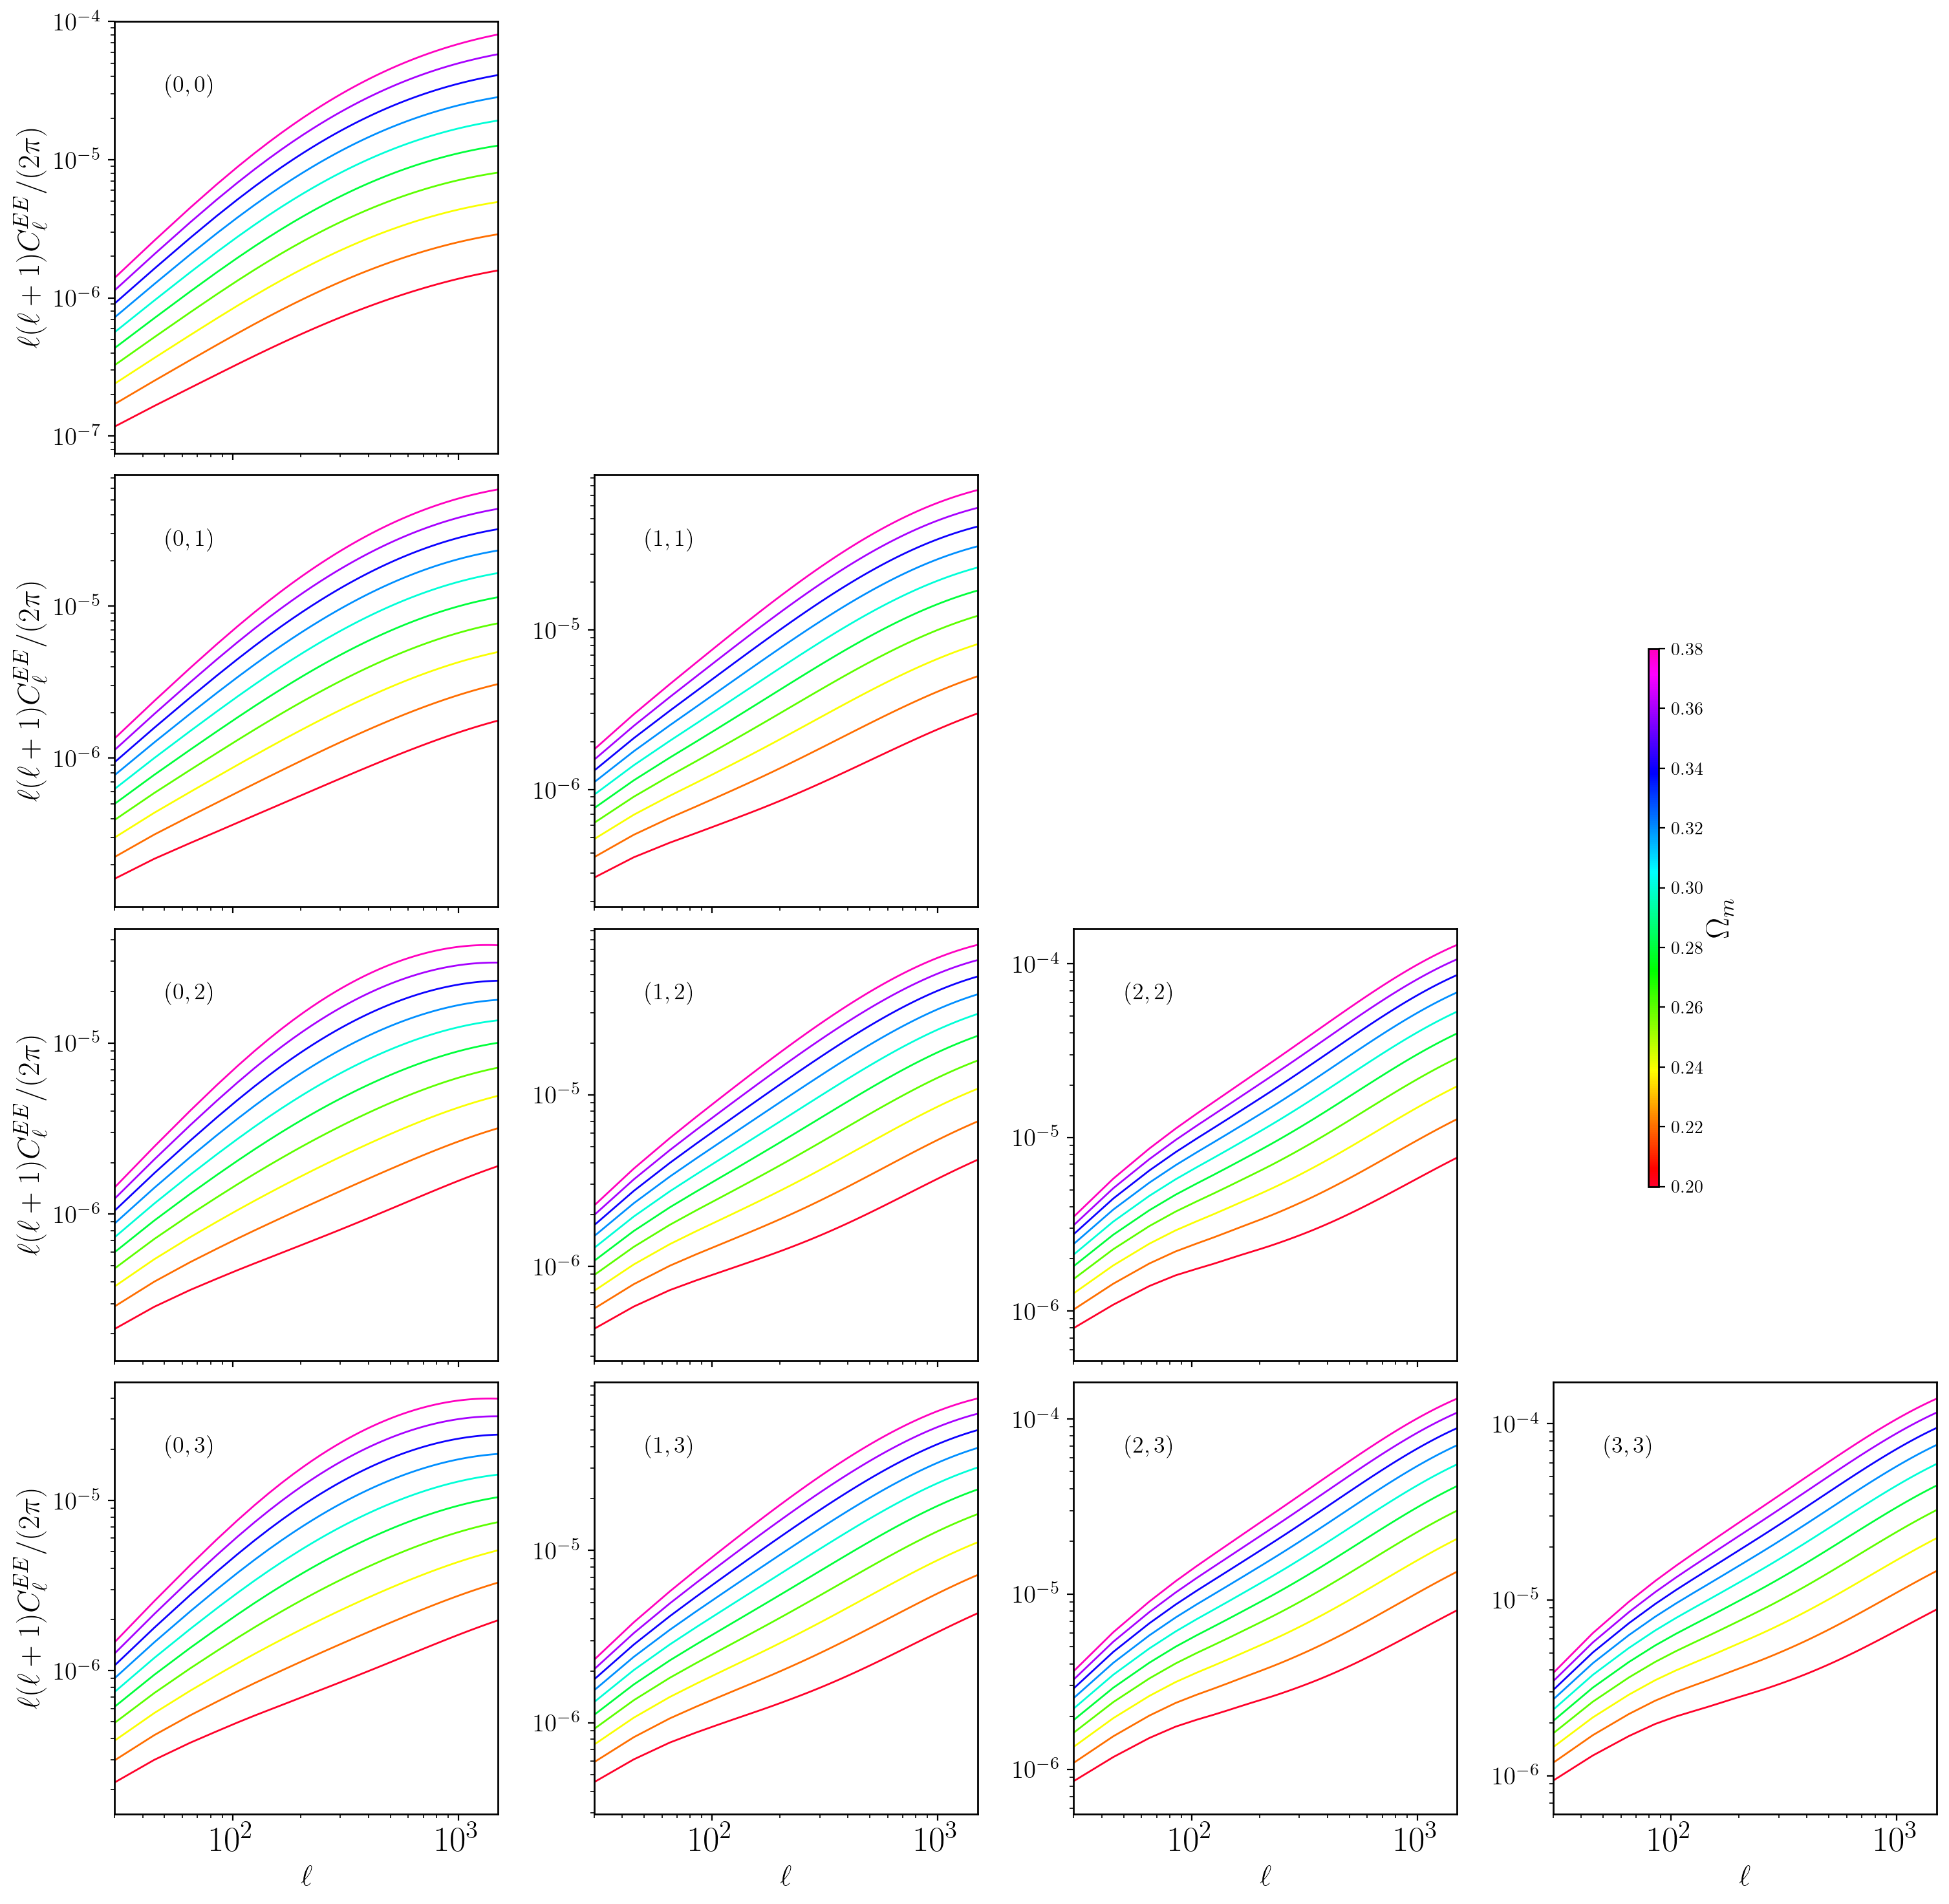

In [12]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          param=param,
                          colorbarlabel="$\Omega_m$",
                          yaxislabelsize = 17,
                          yaxisticklabelsize = 14,
                          xaxisticklabelsize = 20)

In [13]:
ell = np.arange(25., 1500., 20.) # Make sure arange are with float numbers (otherwise there are aliasing problems)

param = np.arange(0.85, 1.1, 0.02)

C_ss = []
for x in param:
    (Cl, tmp) = C_ss_tomo_limber(ell=ell, ns=x)
    C_ss.append(Cl)

# Plot the Ratio over ref cosmology
(ref, tmp) = C_ss_tomo_limber(ell=ell)

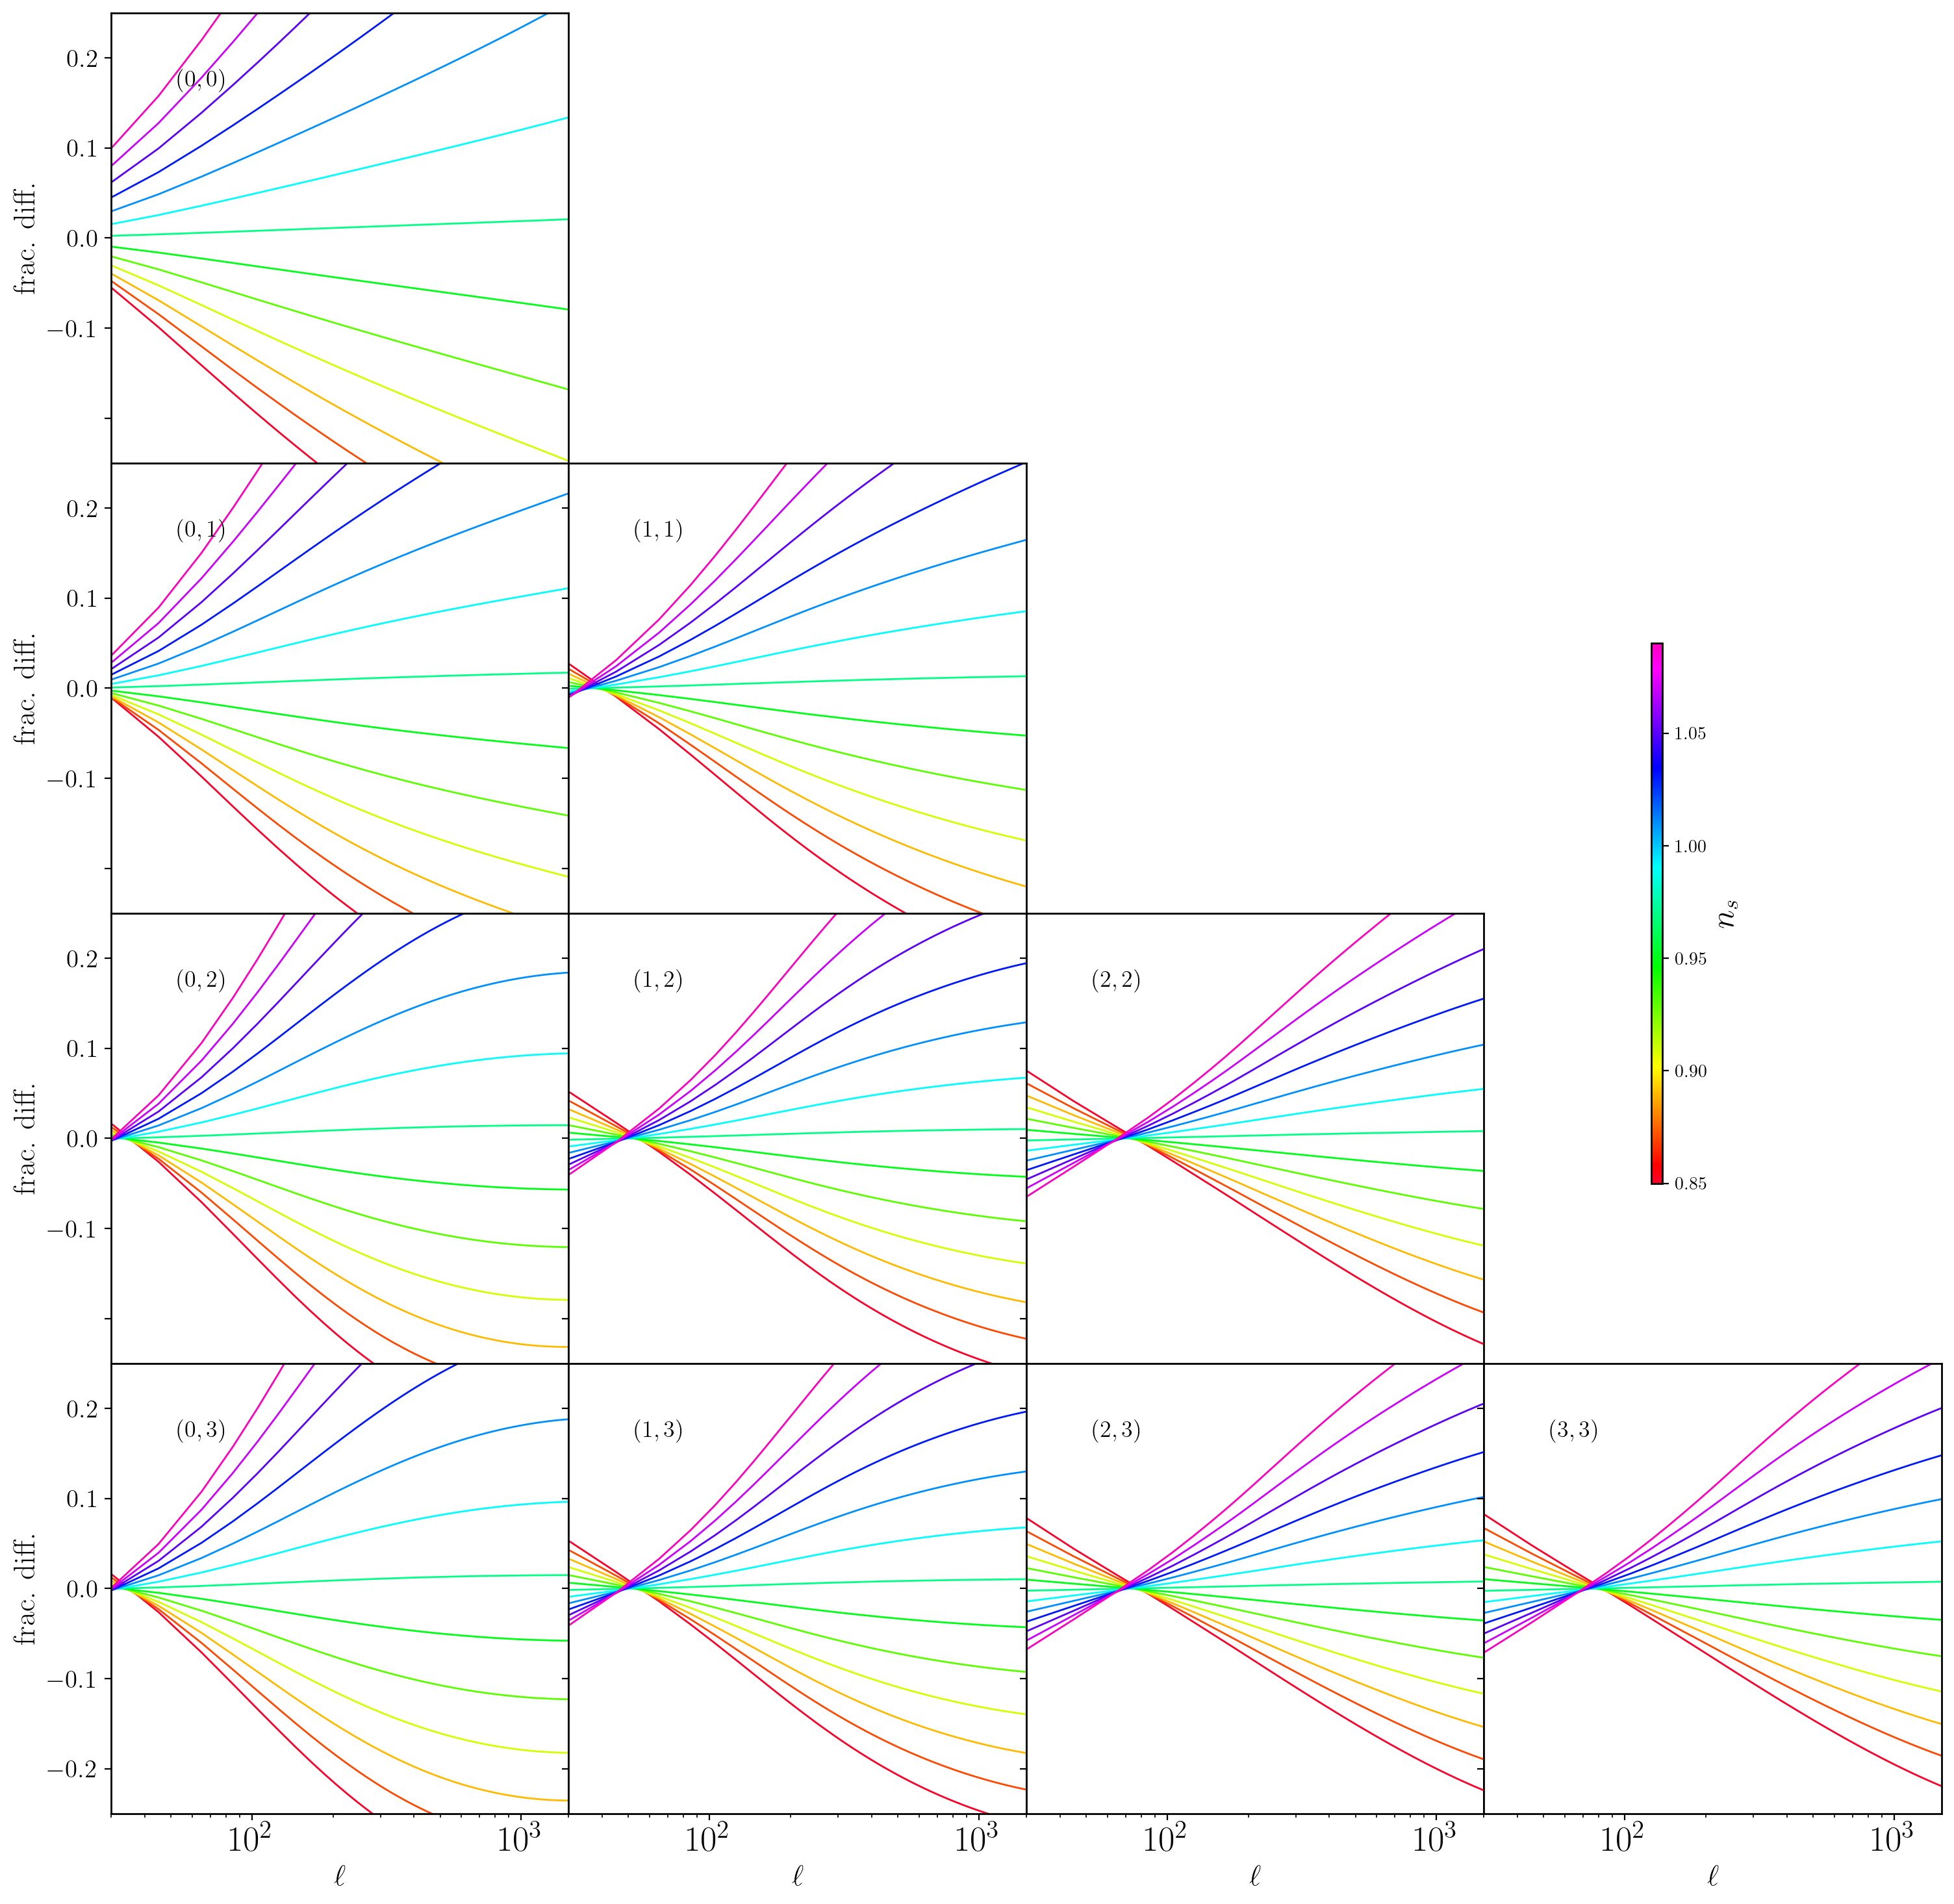

In [14]:
# Reference mode with the default ylim [0.75, 1.25]: the band -25% to +25%
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=ref,
                          param=param,
                          colorbarlabel="$n_s$",
                          yaxislabelsize = 17,
                          yaxisticklabelsize = 14,
                          xaxisticklabelsize = 20)

## How $\Omega_m$ changes $\xi_\pm(\theta)$

The sweep varies $\Omega_m$ from 0.20 to 0.40; each entry of `xi_theta` is the
tuple `(theta, xi_plus, xi_minus)` returned by `xi`. `plot_xi` draws $\xi_+$ for
`pm = 1` and $\xi_-$ for `pm = -1`, as $\theta\,\xi\times10^4$; `thetashow` sets the
horizontal range in arcmin.

$\xi_-$ weights higher multipoles than $\xi_+$ at the same angle, so it probes
smaller physical scales, where baryonic feedback and nonlinear modeling matter
most. This is why the DES Y3 mask removes more of $\xi_-$ (61 of 200 entries
kept) than of $\xi_+$ (166 of 200 kept).

In [15]:
param = np.arange(0.2, 0.41, 0.02)
        
xi_theta = []
for x in param:
    # Each entry is the tuple (theta, xi_plus, xi_minus)
    xi_theta.append(xi(omegam = x))

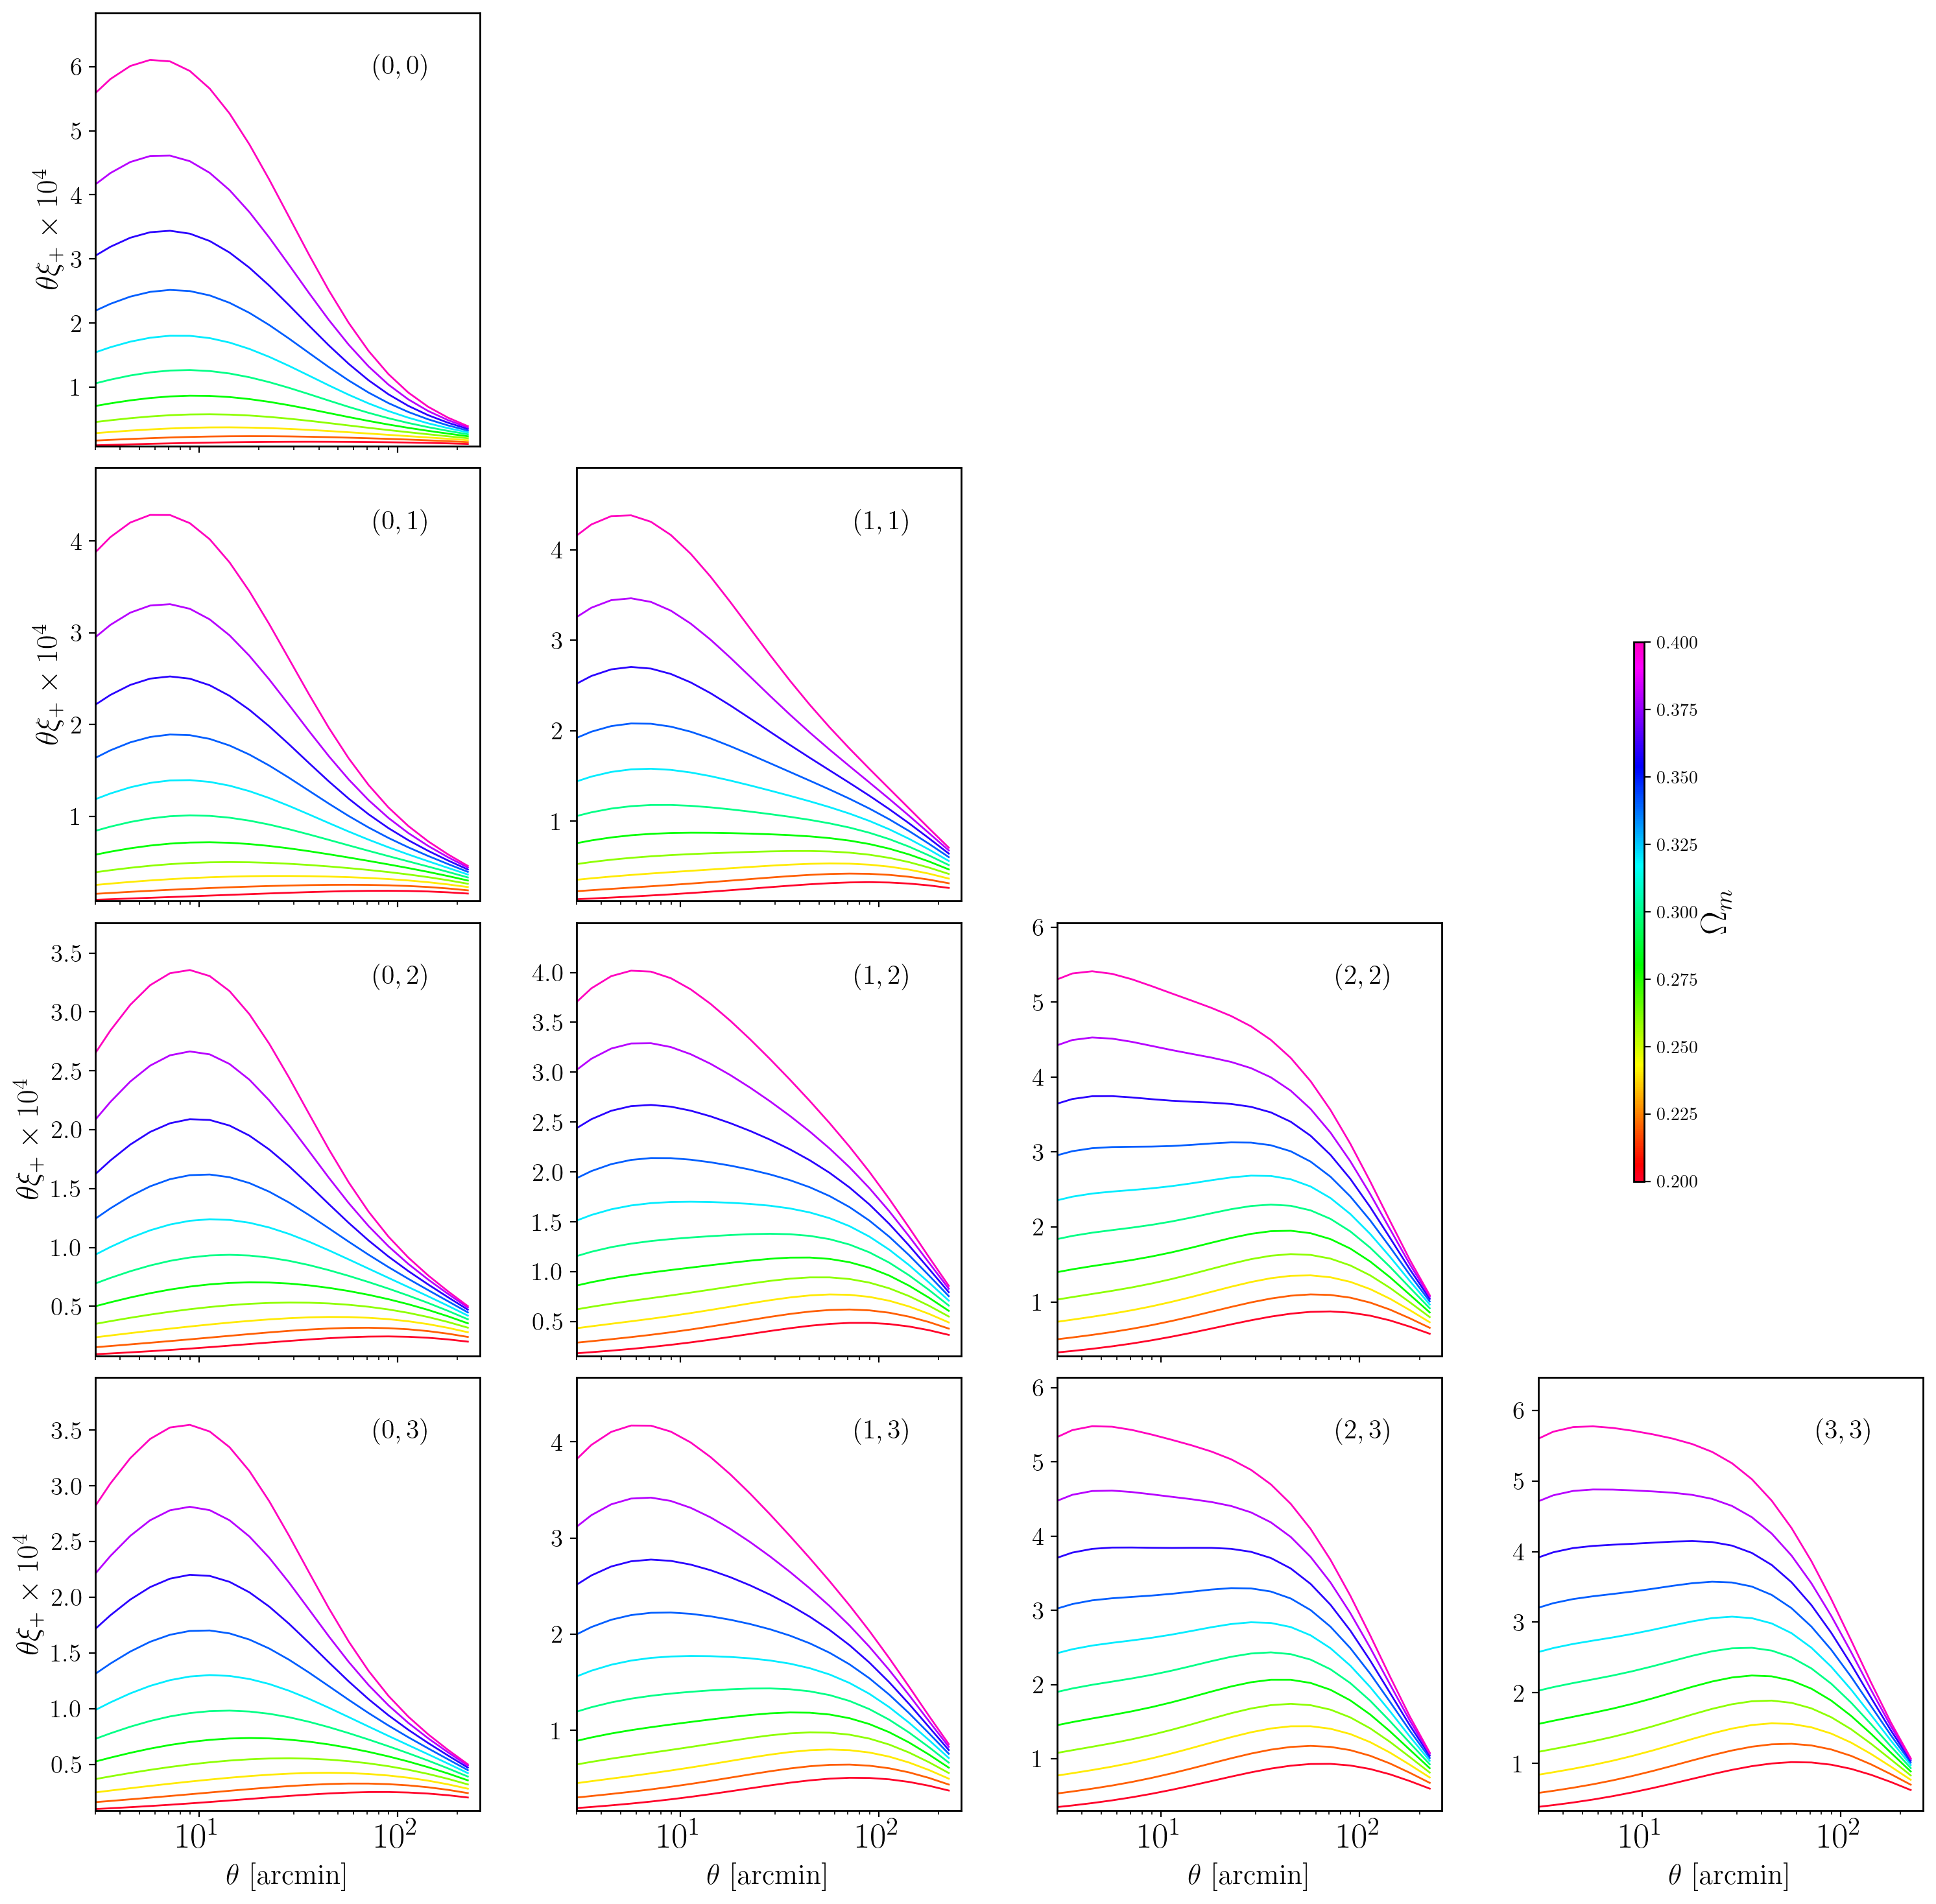

In [16]:
# pm = 1 draws xi_+; thetashow is the horizontal range in arcmin
cnu.plot_xi(pm = 1,
            xi = xi_theta,
            param = param,
            colorbarlabel = "$\Omega_m$",
            thetashow=[3,260],
            yaxislabelsize = 17,
            yaxisticklabelsize = 14,
            xaxisticklabelsize = 20)

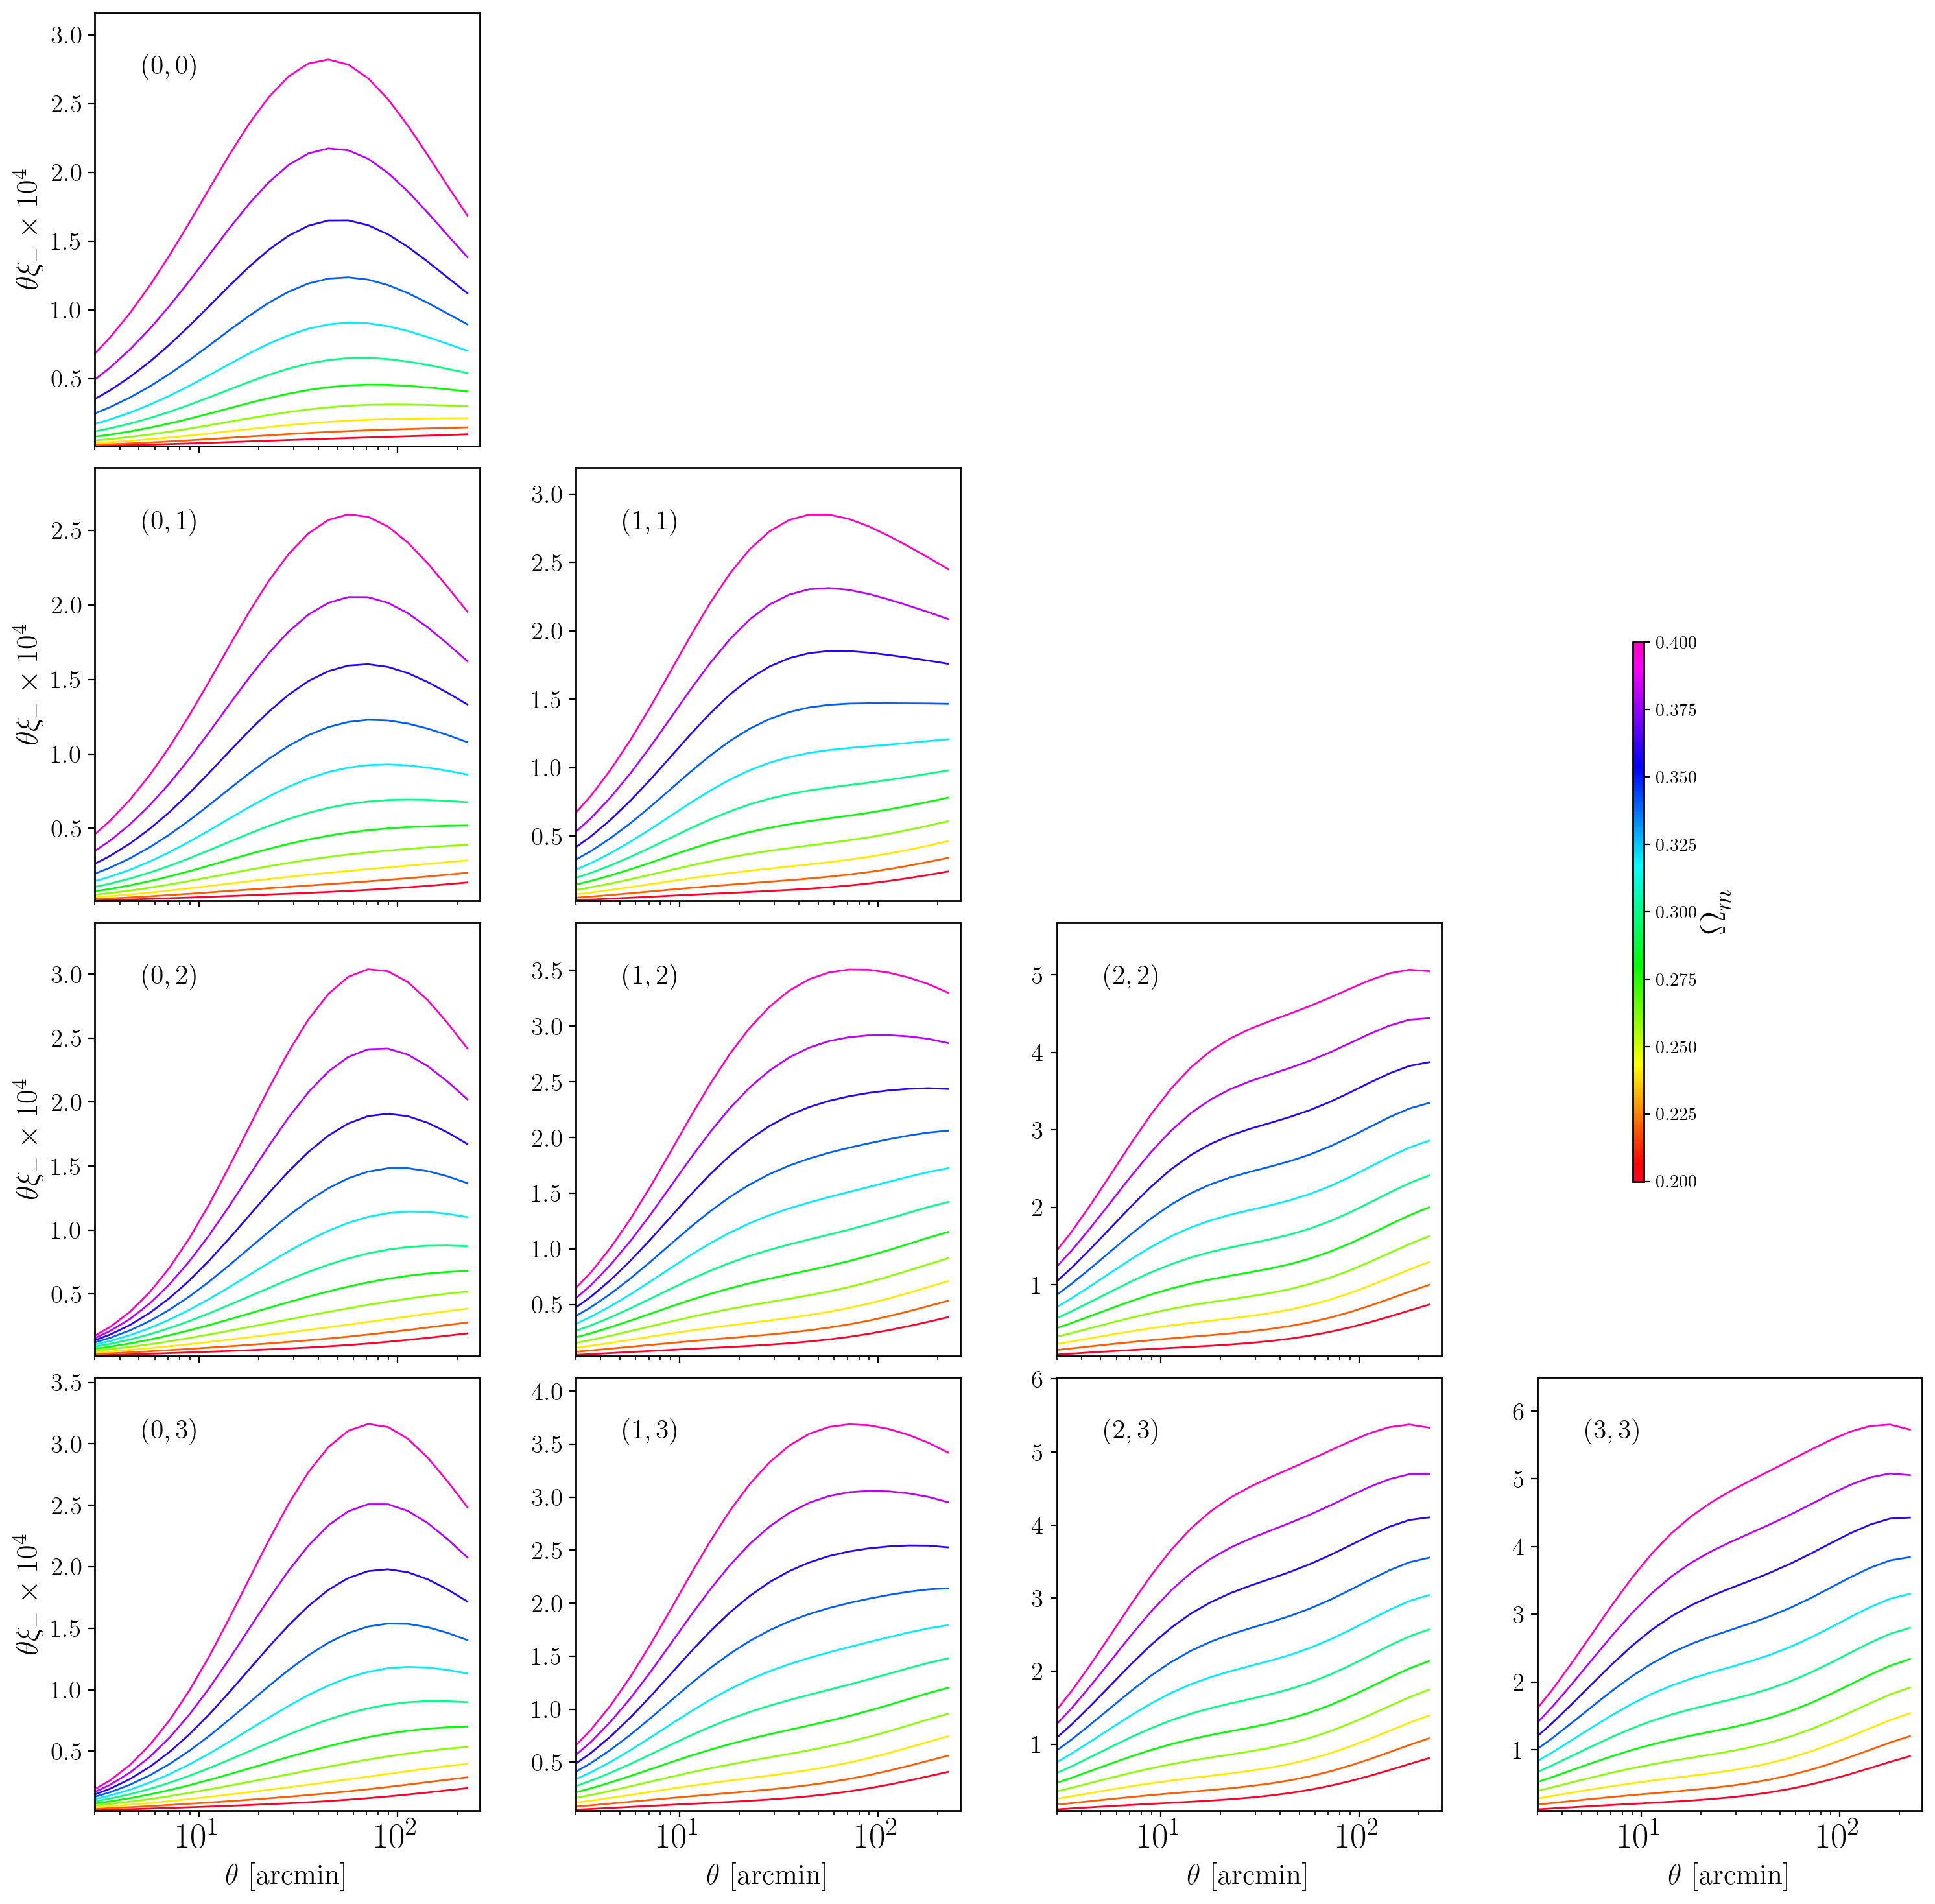

In [17]:
# pm = -1 draws xi_-
cnu.plot_xi(pm = -1,
            xi = xi_theta,
            param = param,
            colorbarlabel = "$\Omega_m$",
            thetashow=[3,260],
            yaxislabelsize = 17,
            yaxisticklabelsize = 14,
            xaxisticklabelsize = 20)

## Changing the angular binning without restarting the kernel

The *kernel* is the Python process that runs the cells. CosmoLike keeps
expensive intermediate results, such as the bin-averaged kernels that turn
$C_\ell$ into $\xi_\pm(\theta)$, in static arrays: C memory that survives between
calls. Each cached table carries a key; `ci.init_binning` assigns a new key
whenever the number of bins or the angular range changes, so the next call
rebuilds the kernels instead of reusing those of the previous binning.

The cell computes $\xi_\pm$ with 9, 12, 17 and 44 bins between 2.5 and 250
arcmin, and the figures mark each binning with its own symbol. The points of all
binnings should follow one smooth curve, wide bins deviating slightly because
each point averages over its bin; a stale cache would instead place the
previous binning's values at the new angles.

In [18]:
nthetas=[9, 12, 17, 44]

result = []
for x in nthetas:
    # A new binning on every call: CosmoLike rebuilds its angular kernels
    result.append(xi(ntheta=x))

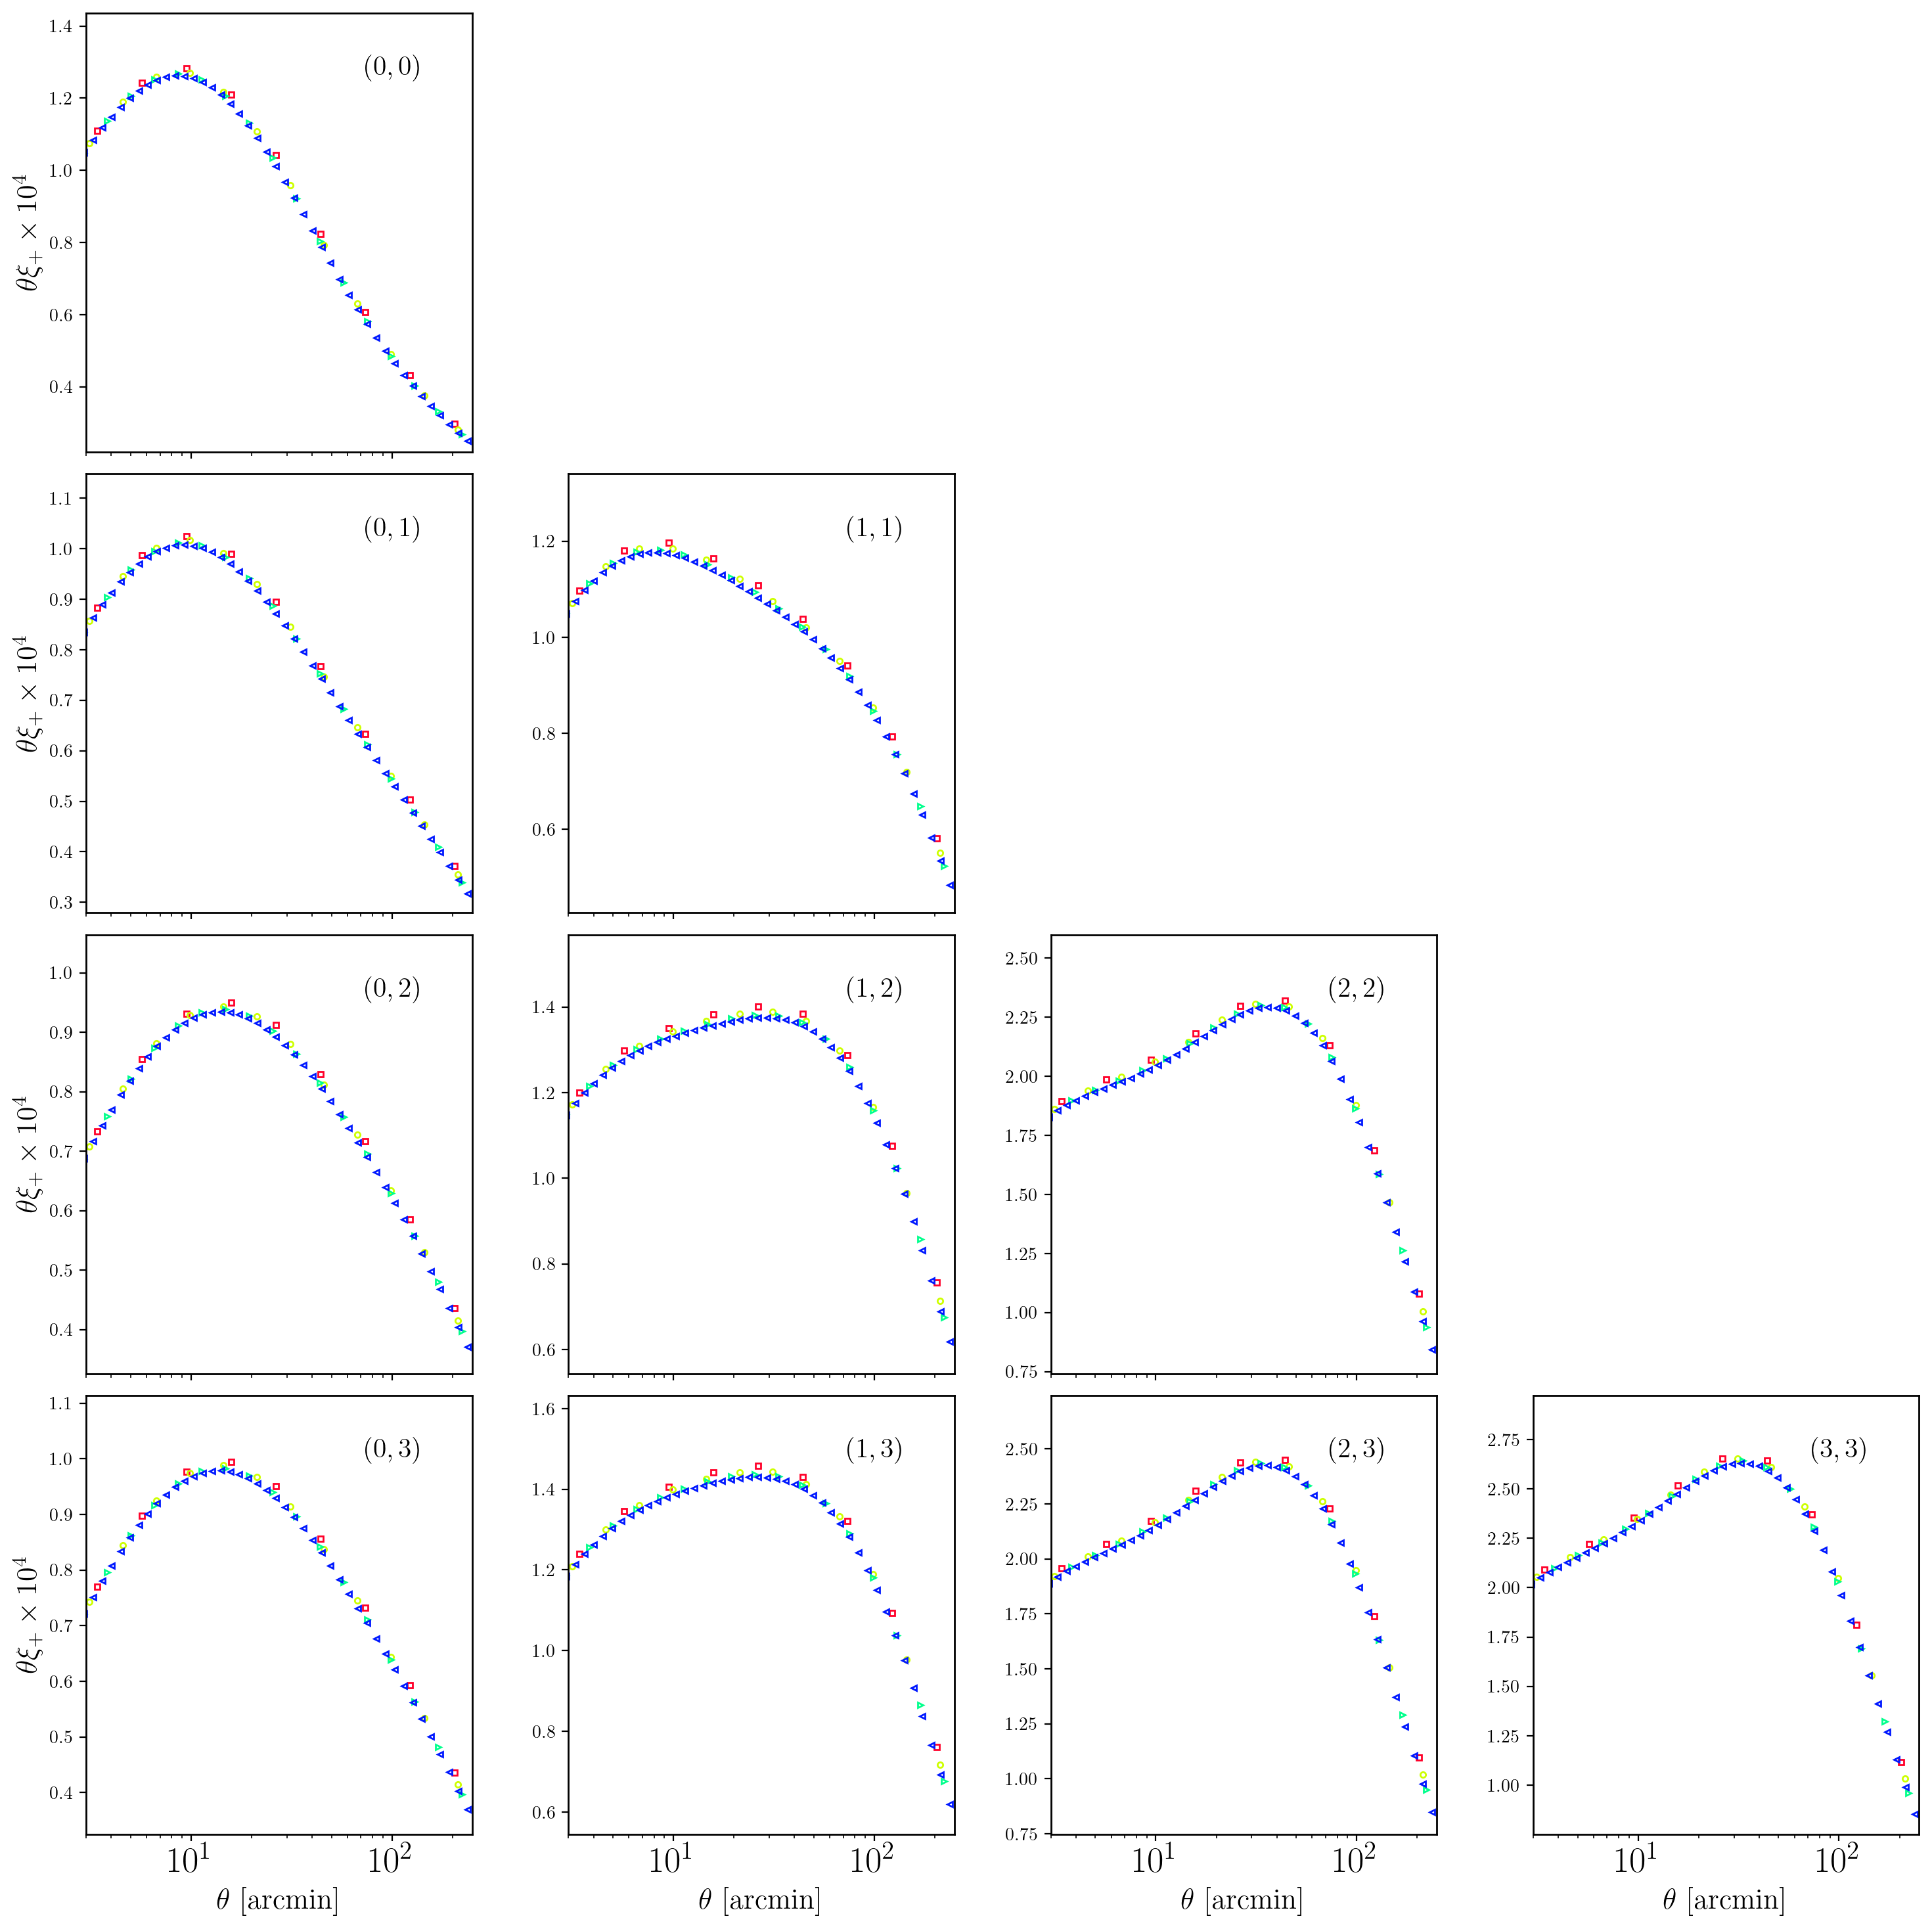

In [19]:
cnu.plot_xi(pm = 1,
            xi = result,
            marker=['s', 'o', ">", "<"])

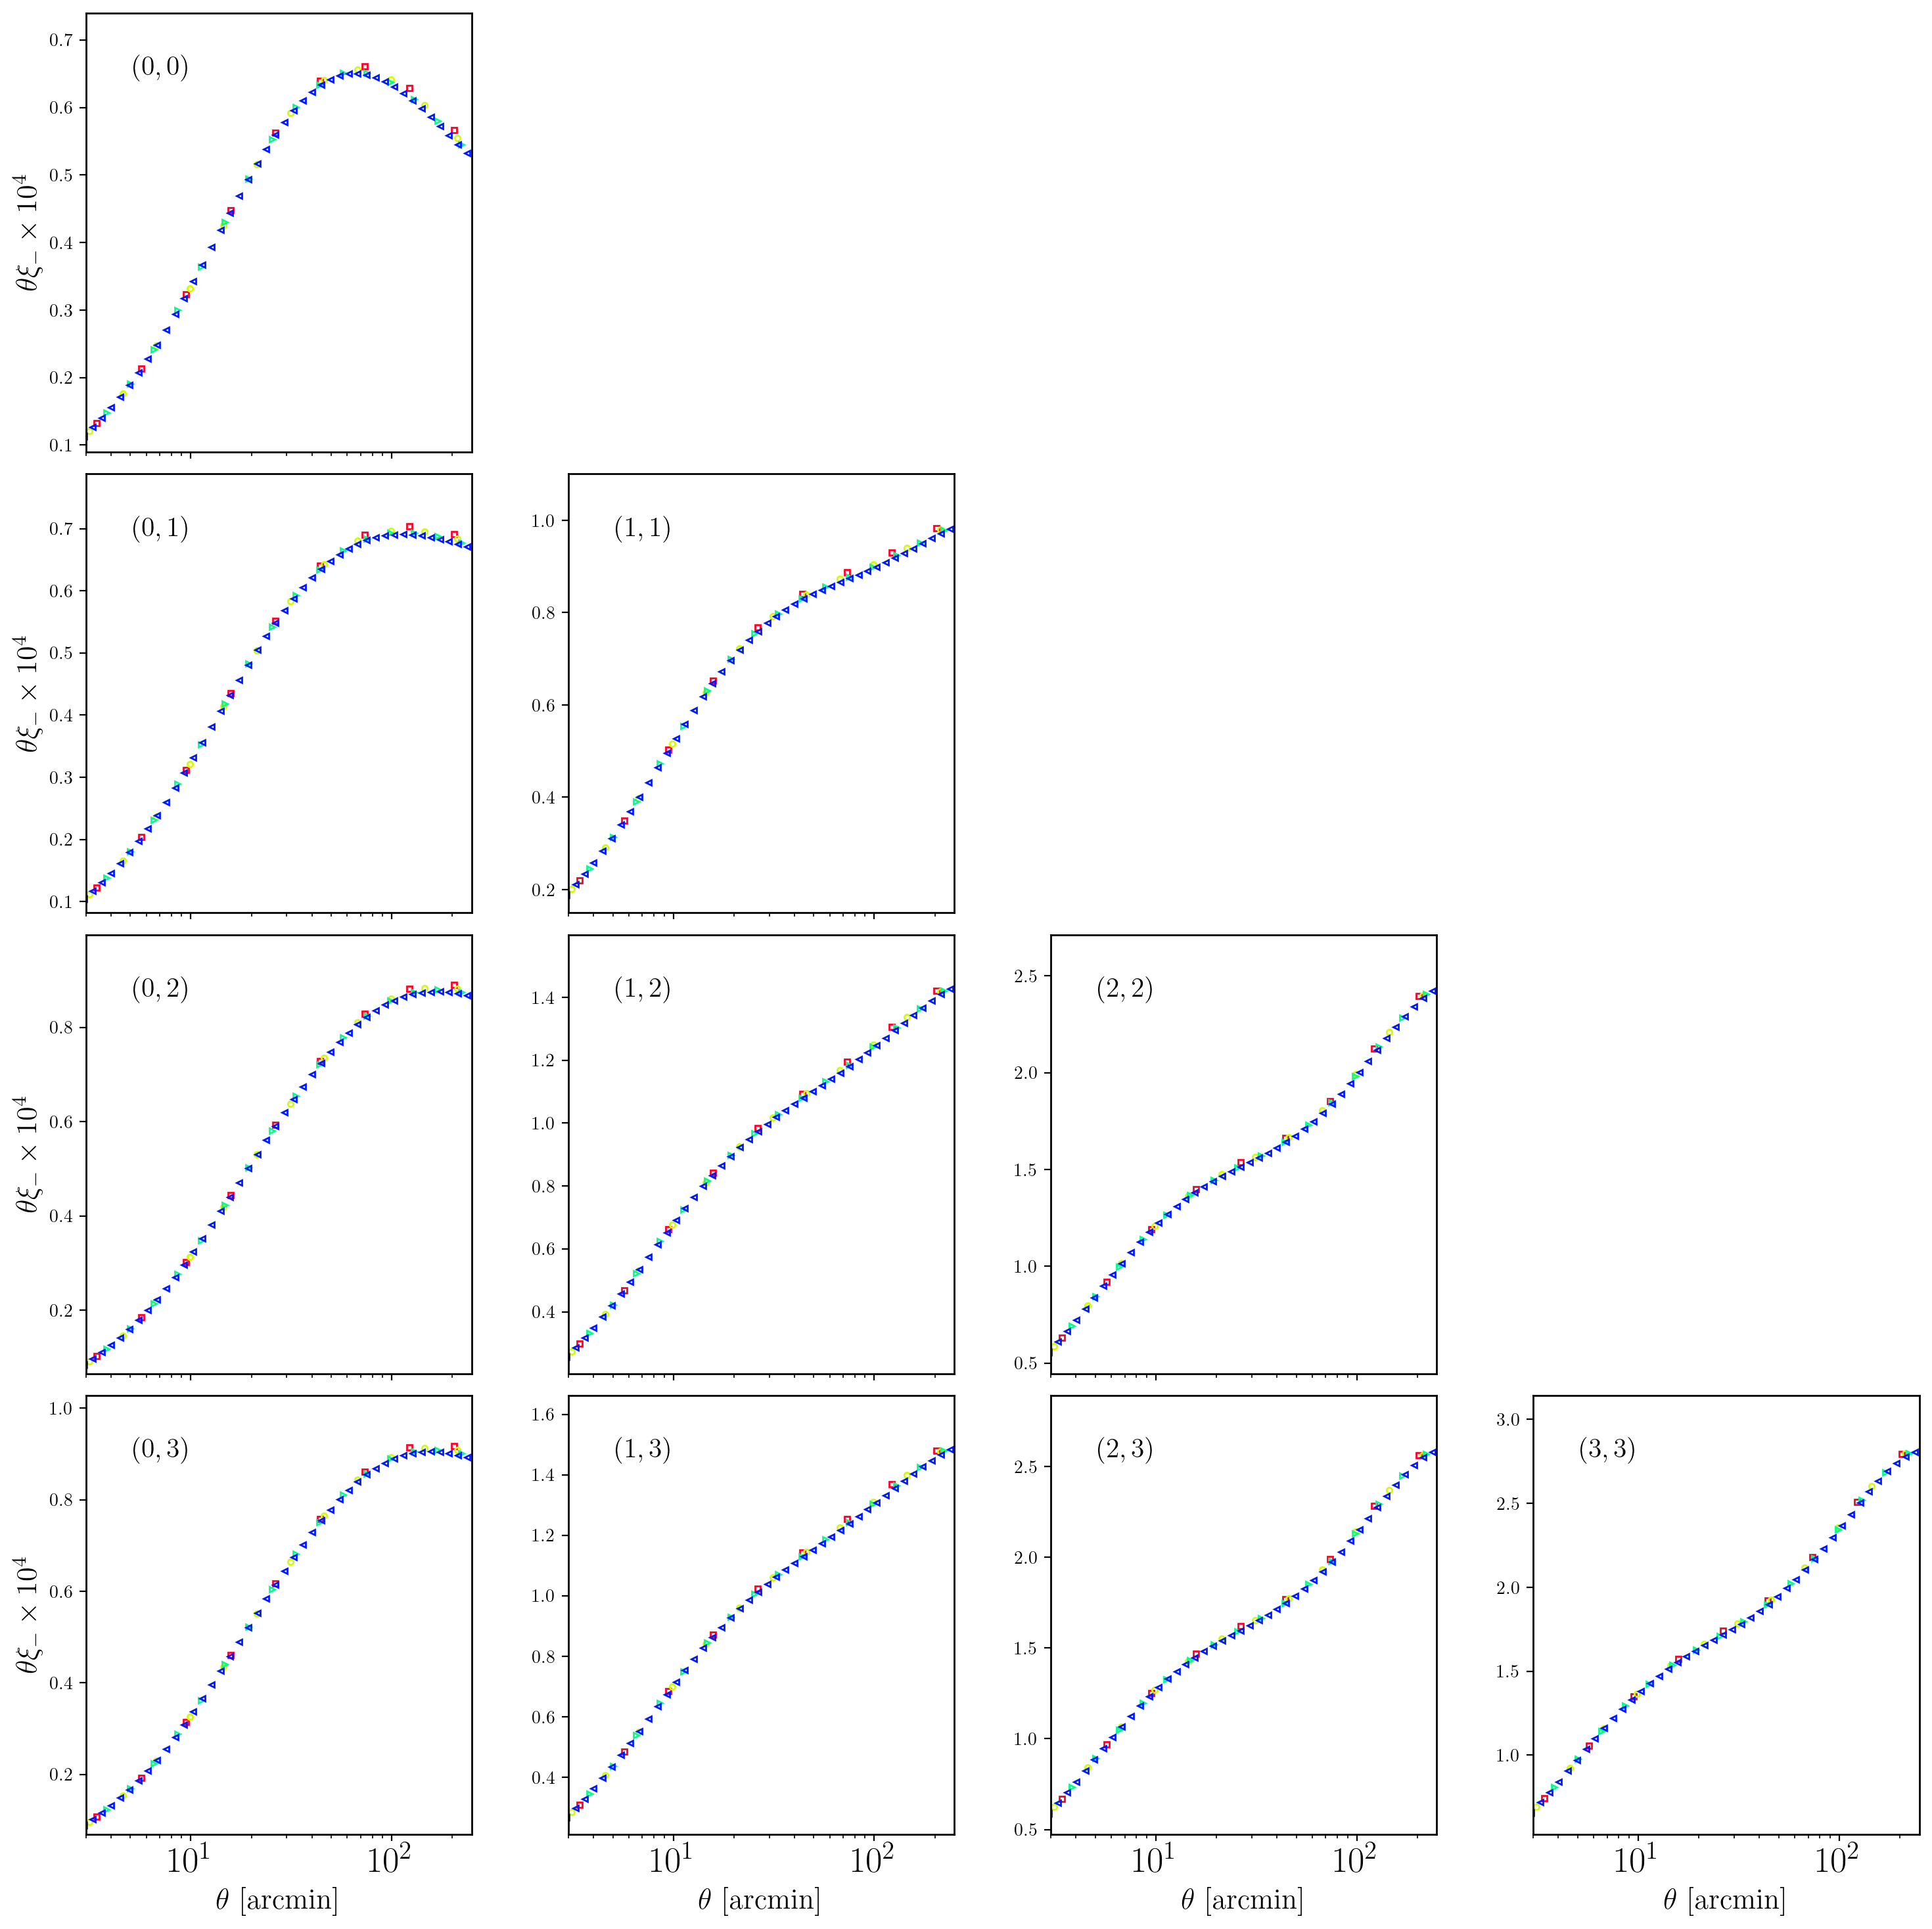

In [20]:
cnu.plot_xi(pm = -1,
            xi = result,
            marker=['s', 'o', ">", "<"])

## Baryonic feedback in $C_\ell^{EE}$ and $\xi_\pm(\theta)$

Gas physics (cooling, star formation, energy injected by supernovae and active
galactic nuclei) moves matter inside and around halos and changes the matter
power spectrum at small scales. `ci.init_baryons_contamination(sim, allsims)`
multiplies CosmoLike's matter power by the ratio of the power spectrum of one
hydrodynamical simulation to that of its dark-matter-only counterpart, tabulated
in the HDF5 file (a binary table format) `baryons_logPkR.h5` named in the dataset.

The cells compute the nine scenarios listed in `param` and the fiducial without
baryons, then draw each scenario relative to the fiducial ($C/C^{\rm fid}-1$ and
$\xi/\xi^{\rm fid}-1$), named by a legend instead of a colorbar. The real-space
curves use 40 angular bins, for smoother lines.

In [21]:
ell = np.arange(3., 7500., 10.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
# Simulation names in the HDF5 table baryons_logPkR.h5
param = ("TNG100-1", "HzAGN-1", "mb2-1", "illustris-1", "eagle-1", "owls_AGN-1", "owls_AGN-2", "owls_AGN-3", "BAHAMAS-2")
        
C_ss = []
for x in param:
    (Cl, tmp) = C_ss_tomo_limber(ell=ell, baryon_sims=x)
    C_ss.append(Cl)
    
# Plot the Ratio over ref cosmology
(C_ss_ref, tmp) = C_ss_tomo_limber(ell=ell)

xi_theta = []
for x in param:
    # 40 angular bins draw smoother curves than the 20 of the data vector
    xi_theta.append(xi(baryon_sims=x, ntheta=40, AccuracyBoost=1.0))

xi_theta_ref = xi(ntheta=40, AccuracyBoost=1.0)

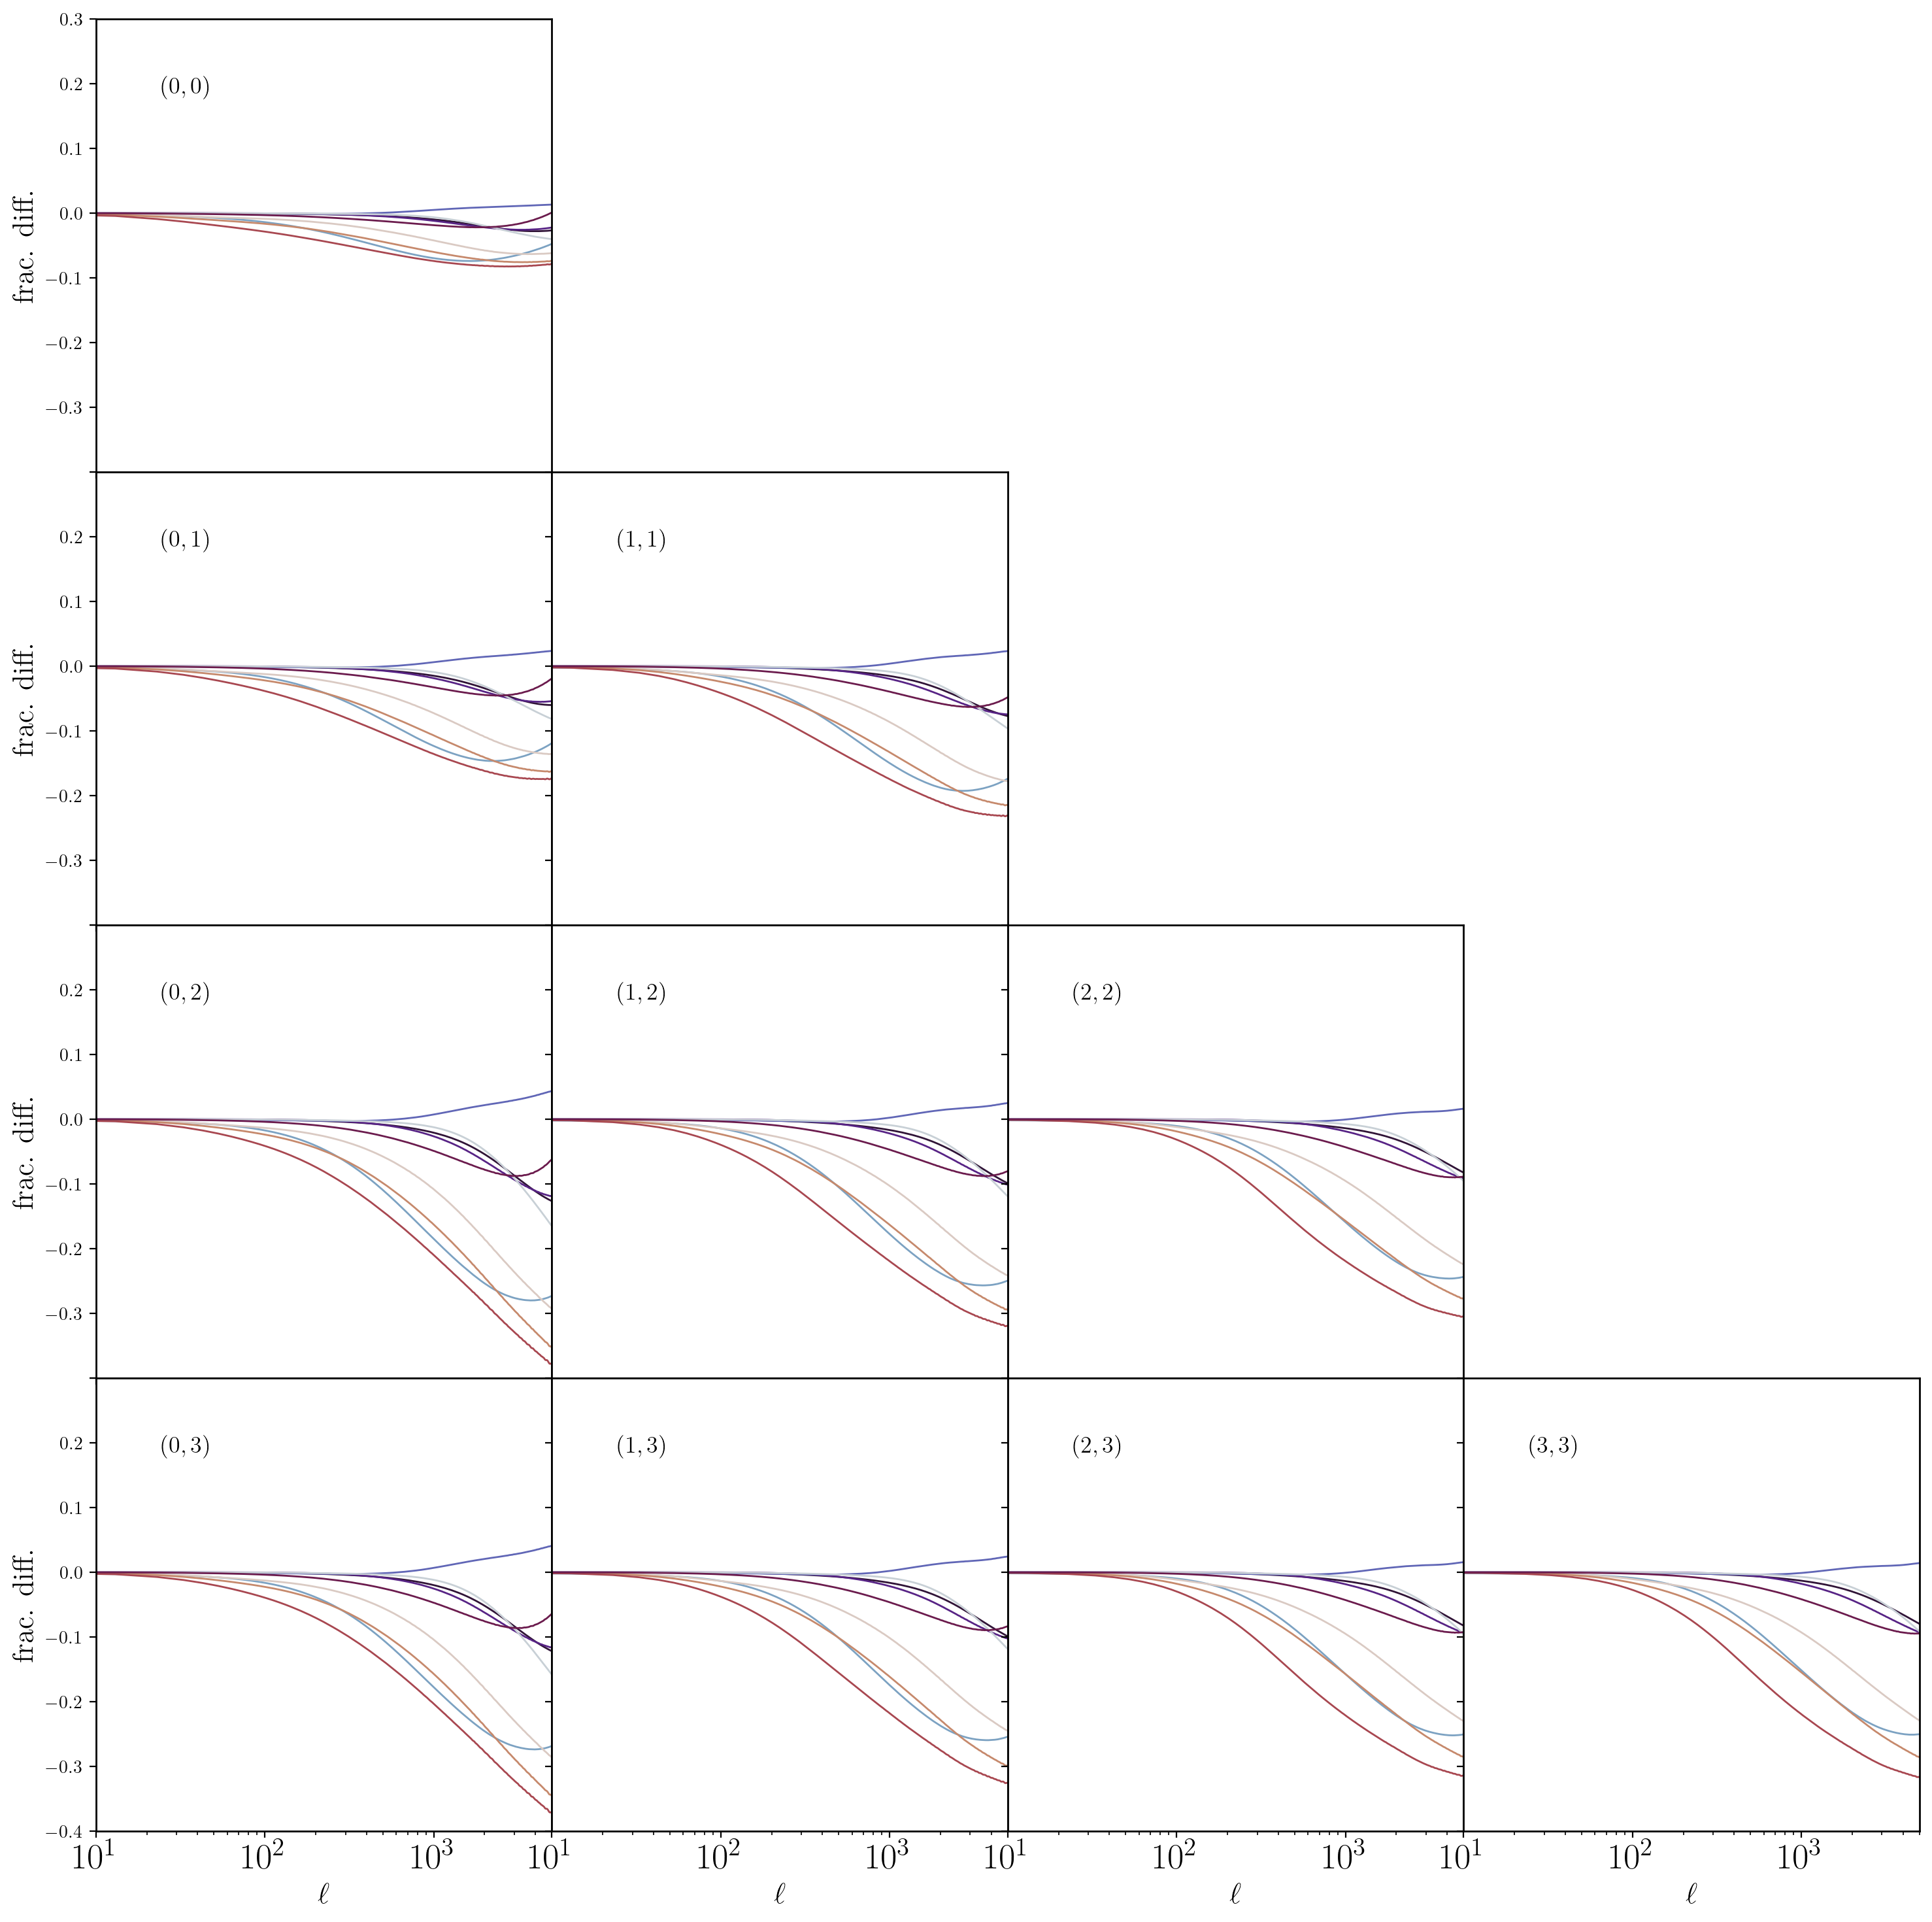

In [22]:
# ylim (0.6, 1.3): the band -40% to +30% of C/C_ref - 1
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=C_ss_ref,
                          lmin=10,
                          lmax=5000,
                          cmap="twilight_shifted",
                          ylim=(0.6,1.3))

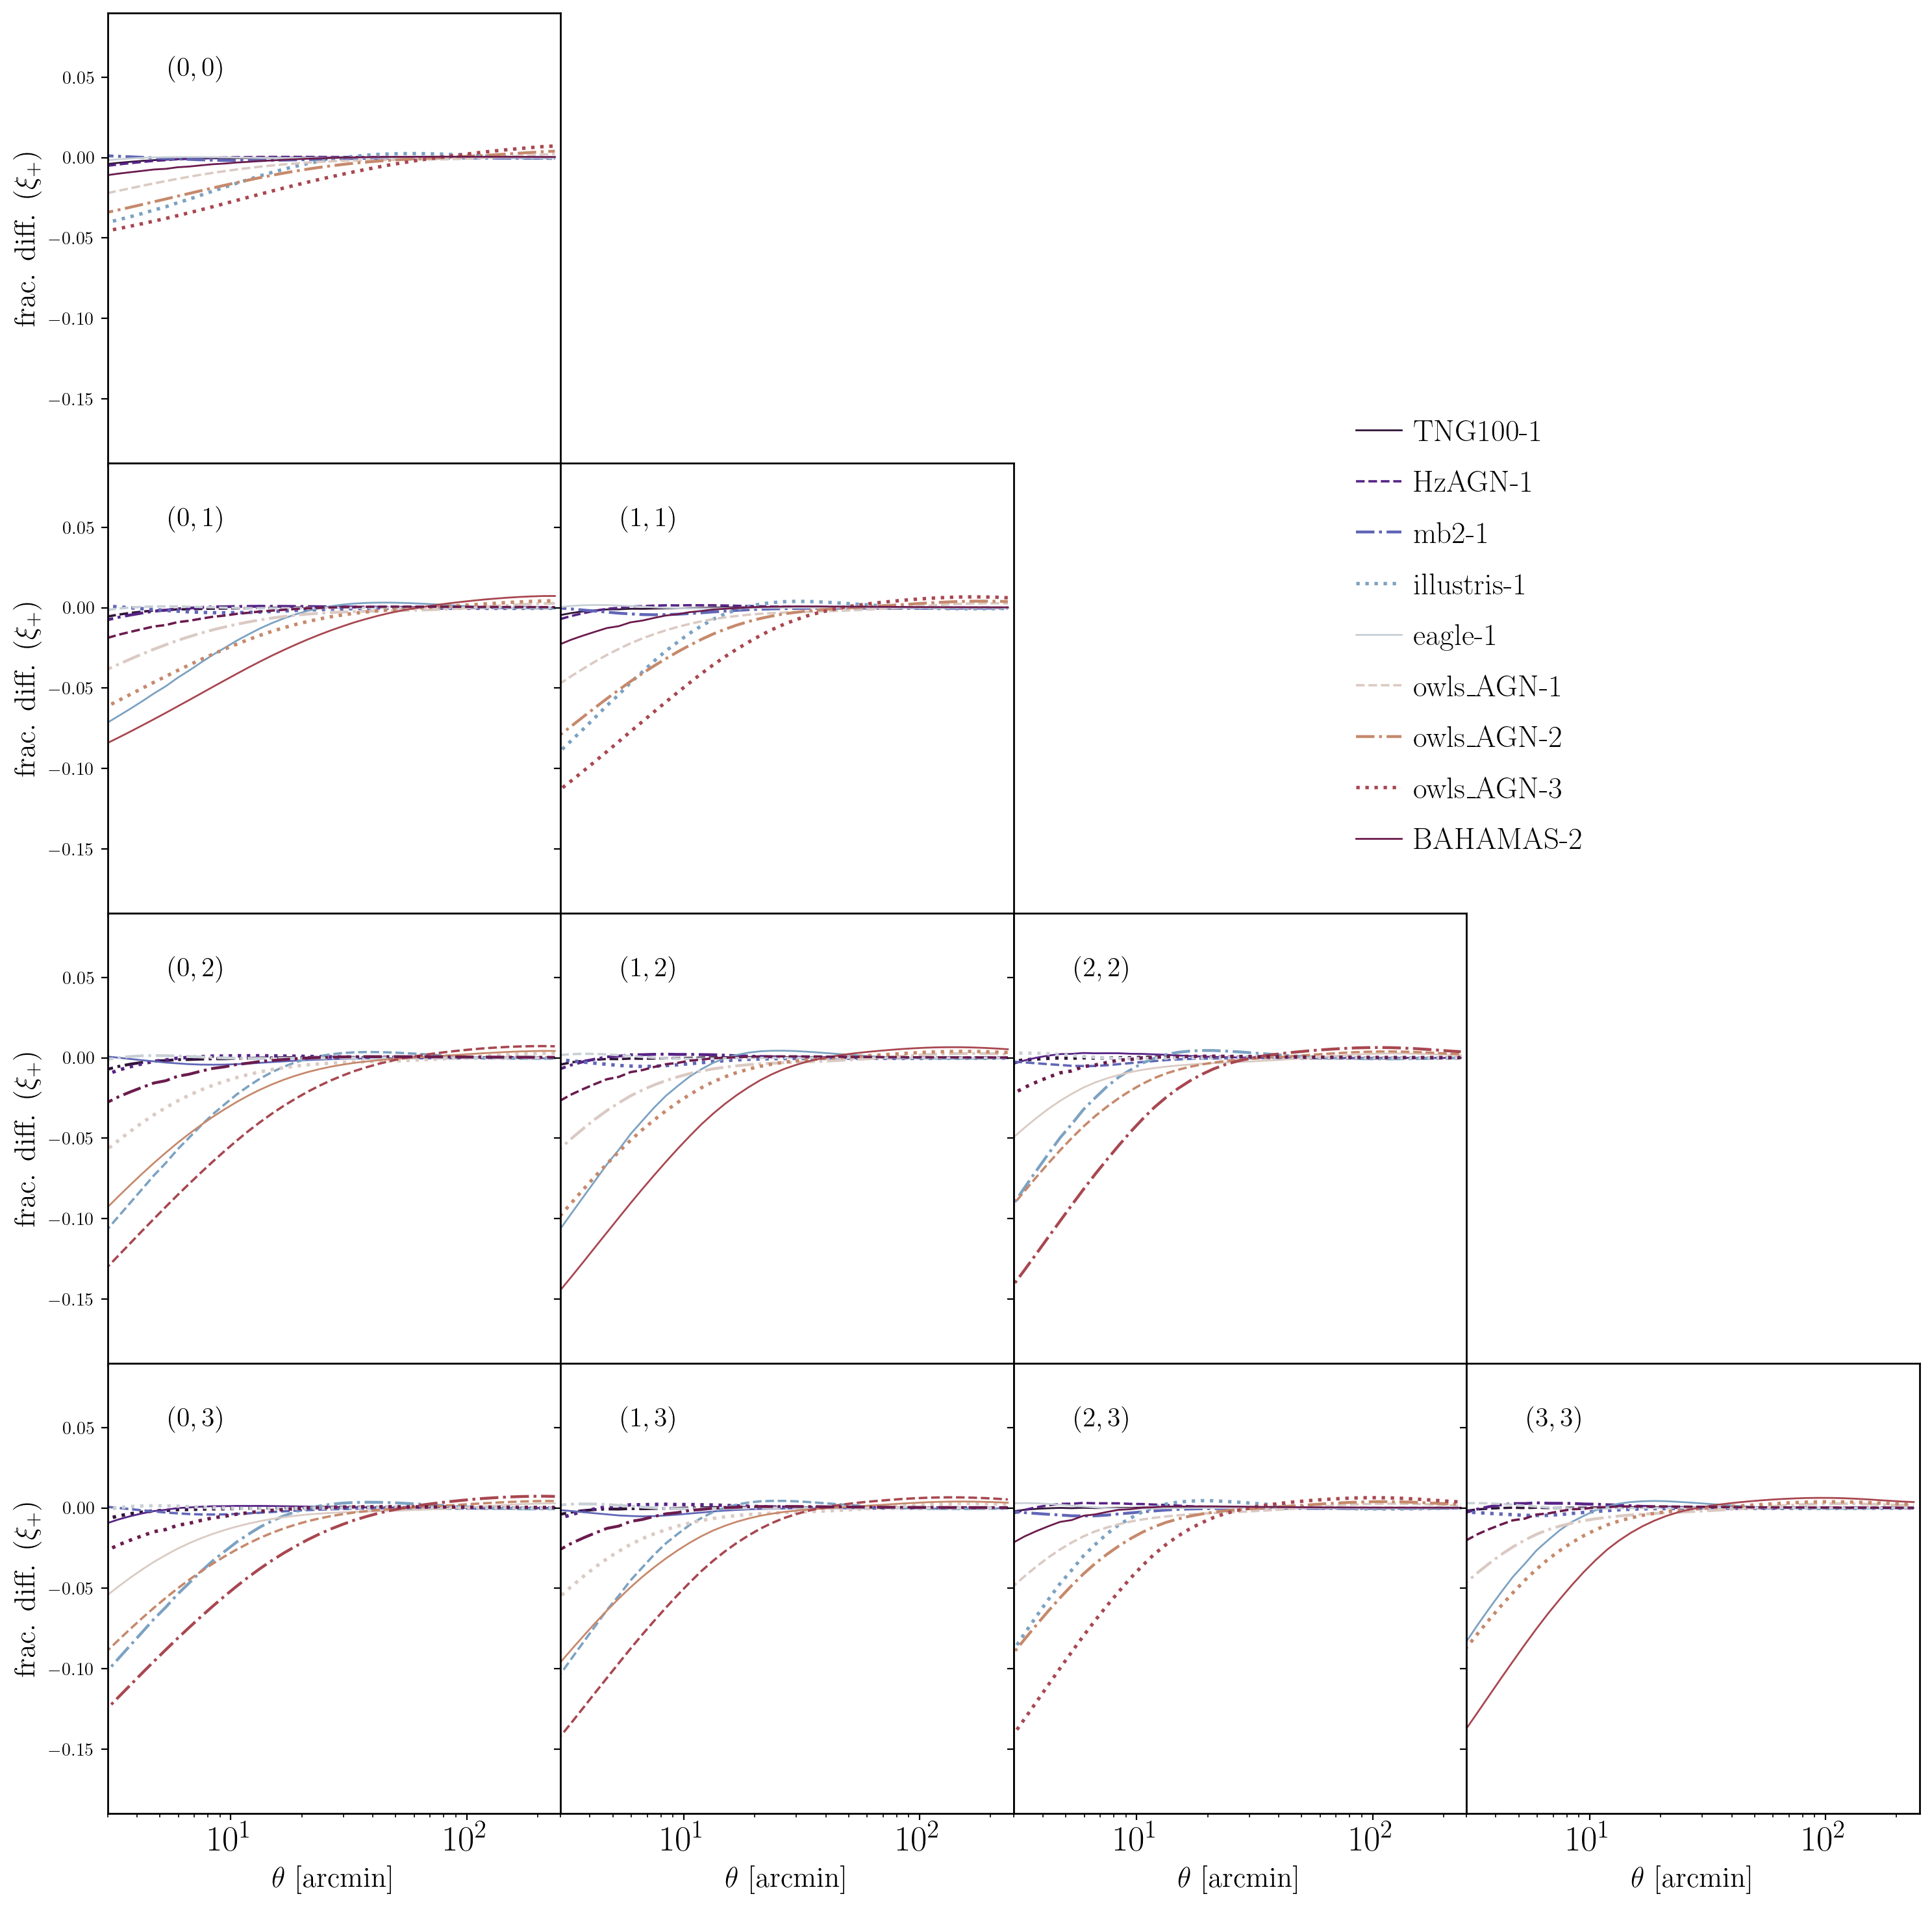

In [23]:
# rcParams are global: every later figure uses this legend font size
matplotlib.rcParams['legend.fontsize'] = 17
 
# legend names the curves instead of a colorbar; ylim (0.81, 1.09) is the
# band -19% to +9% of xi/xi_ref - 1
cnu.plot_xi(pm = 1,
            param=None,
            xi=xi_theta,
            xi_ref=xi_theta_ref,
            cmap="twilight_shifted",
            ylim=(0.81,1.09),
            linewidth=[1.0, 1.3, 1.6, 1.9],
            linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
            legend = param,
            legendloc=(0.7,0.55),
            bintextpos = [[0.2, 0.875],[0.2,0.875]])

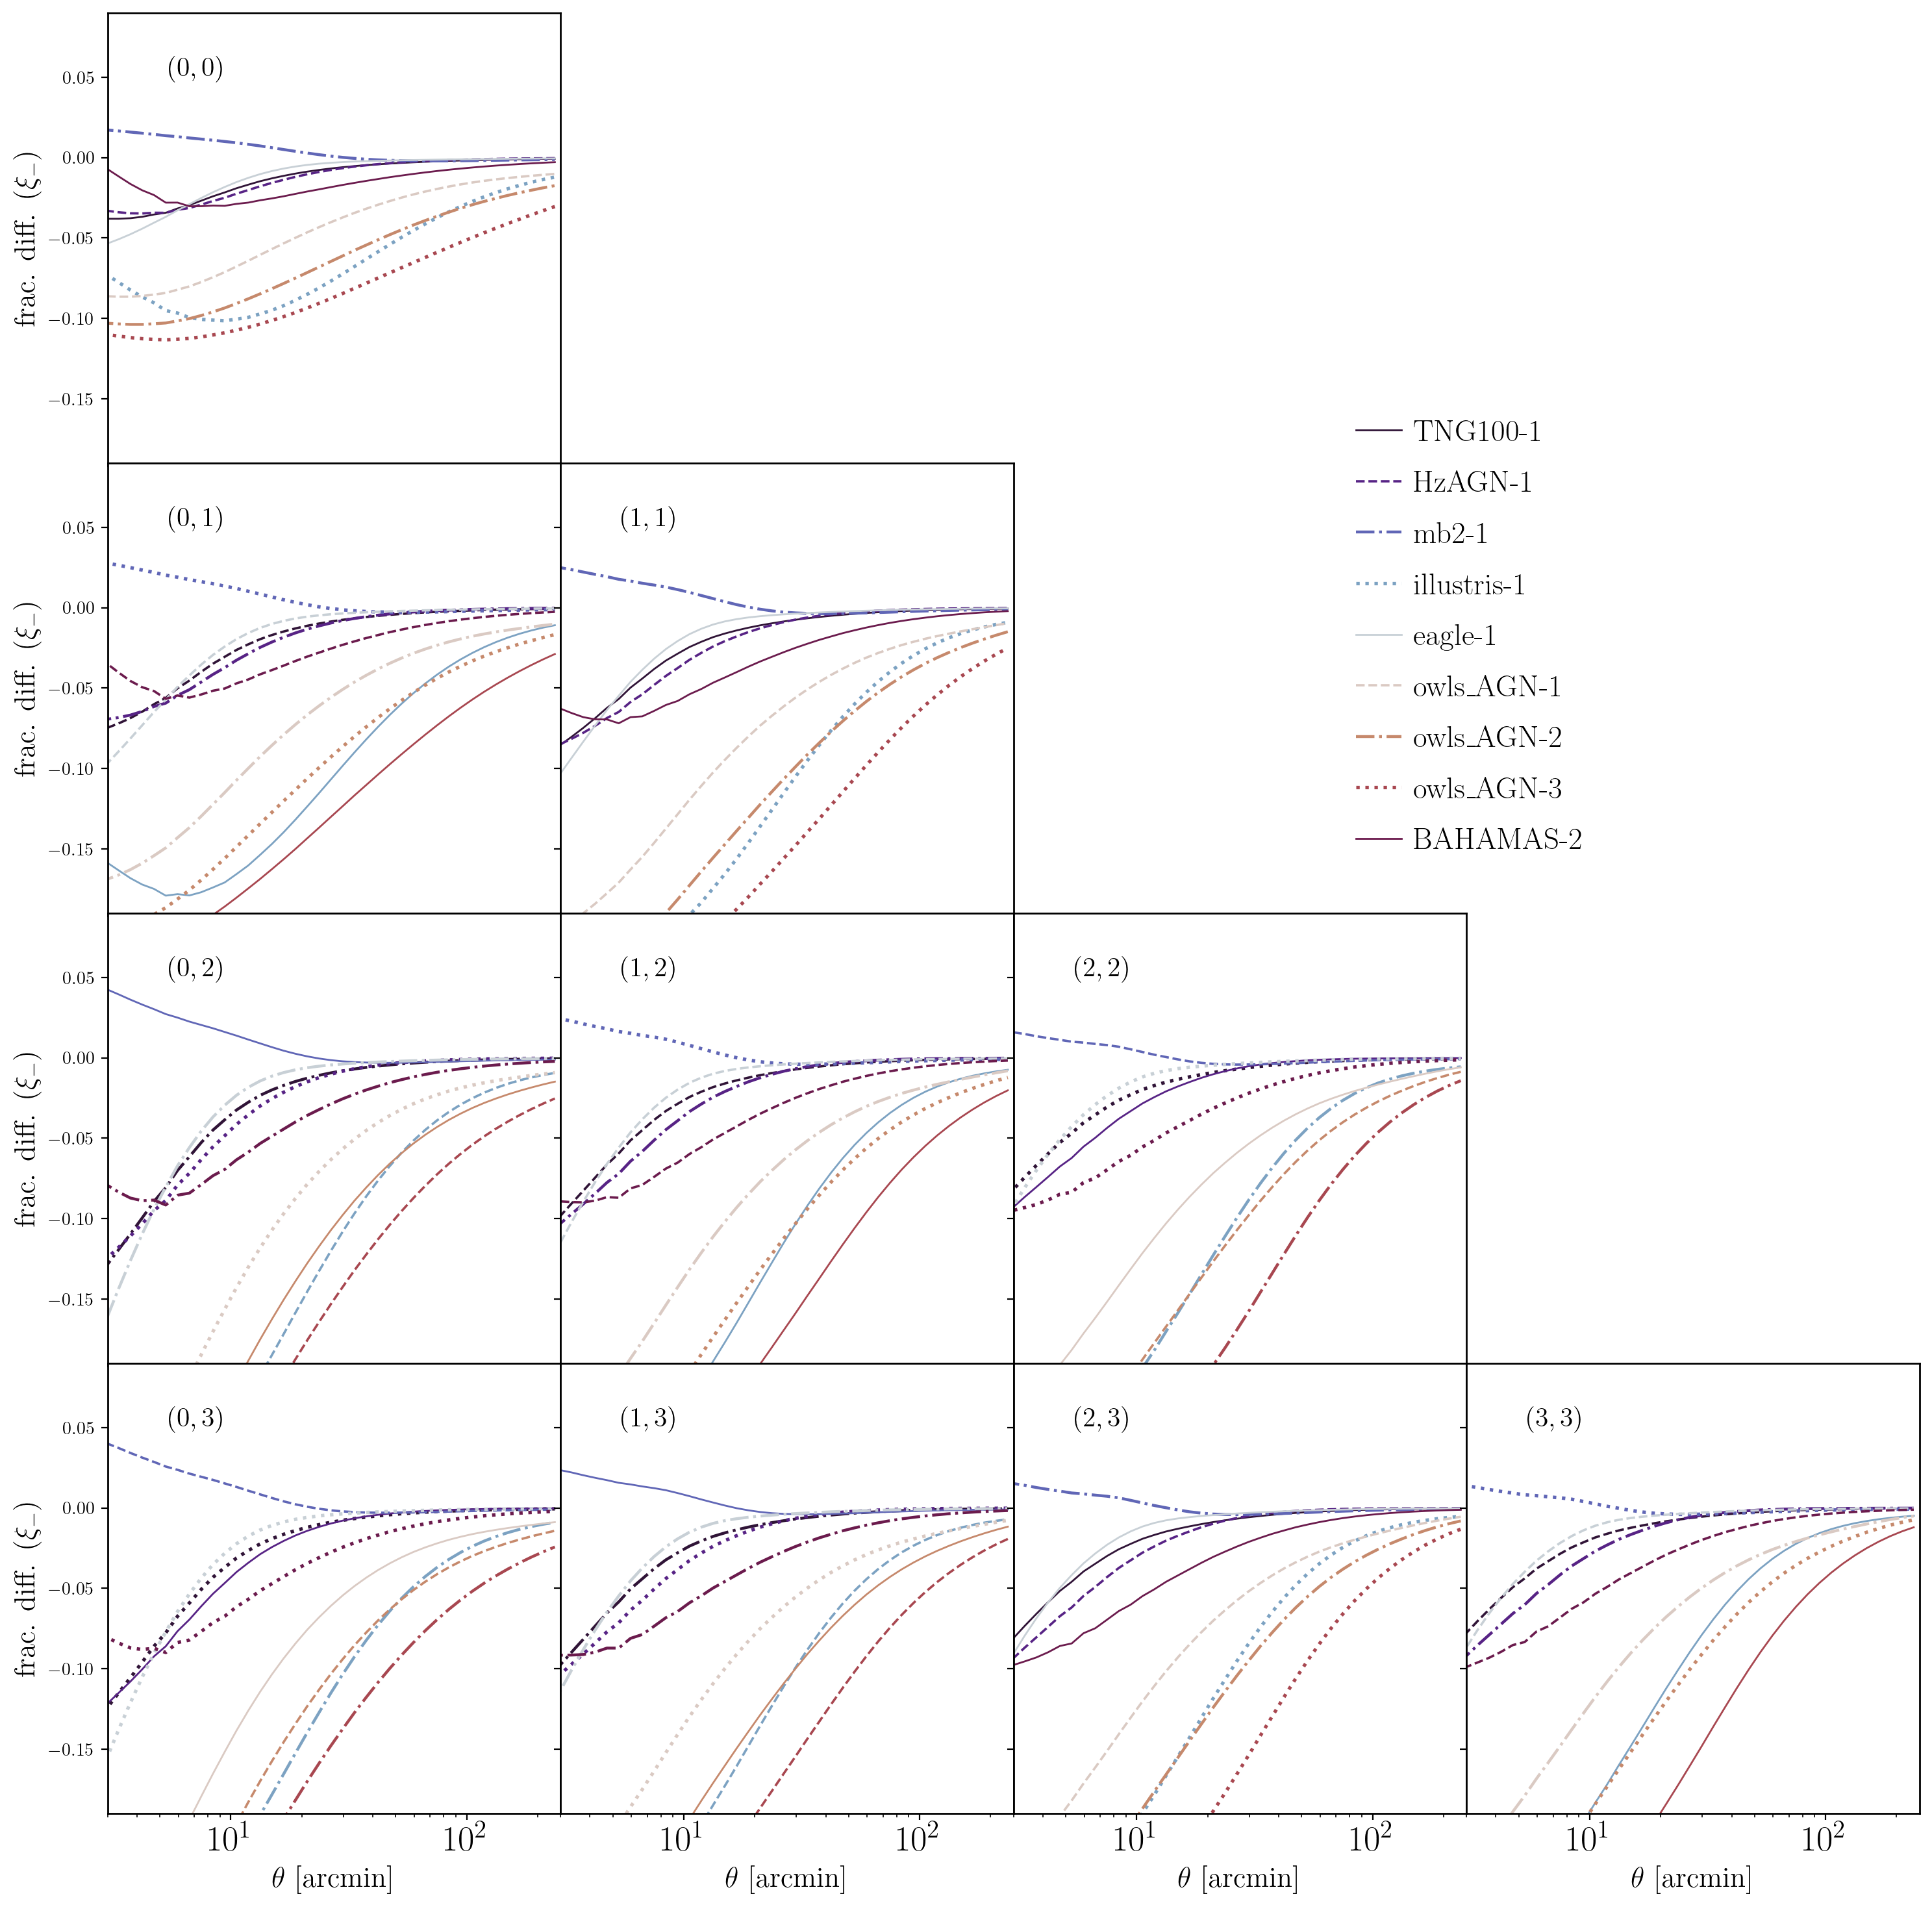

In [24]:
cnu.plot_xi(pm = -1,
            param=None,
            xi=xi_theta,
            xi_ref=xi_theta_ref,
            cmap="twilight_shifted",
            ylim=(0.81,1.09),
            linewidth=[1.0, 1.3, 1.6, 1.9],
            linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
            legend = param,
            legendloc=(0.7,0.55),
            bintextpos = [[0.2, 0.875],[0.2,0.875]])

## Accuracy settings: how `AccuracyBoost` changes $C_\ell^{EE}$ and $\xi_+(\theta)$

`AccuracyBoost` refines three things together: CAMB runs with accuracy
$1.1\times(1+(\texttt{AccuracyBoost}-1)/3)$, the CosmoLike tables and the CAMB
grids grow with `AccuracyBoost`, and the wrapper raises the quadrature level by
$|3(\texttt{AccuracyBoost}-1)|$, rounded down, so a boost below 1 raises it too.

The spectra use `AccuracyBoost` from 0.45 to 1.95 in steps of 0.25 and the
$\xi_+$ curves 0.50 to 1.75, each drawn relative to `AccuracyBoost = 1`, on bands
of $\pm4\%$ and $\pm1\%$. The $\chi^2$ sections below express such differences as
$\Delta\chi^2$ against the DES Y3 covariance.

In [25]:
ell = np.arange(10., 8500., 30.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)

# AccuracyBoost 0.45 to 1.95 refines CAMB, the CosmoLike tables and the
# quadrature level together
param = np.arange(0.45, 2.0, 0.25)
        
C_ss = []
for x in param:
    (Cl, tmp) = C_ss_tomo_limber(ell=ell, AccuracyBoost=x)
    C_ss.append(Cl)

# Plot the Ratio over ref cosmology
(C_ss_ref, tmp) = C_ss_tomo_limber(ell=ell)

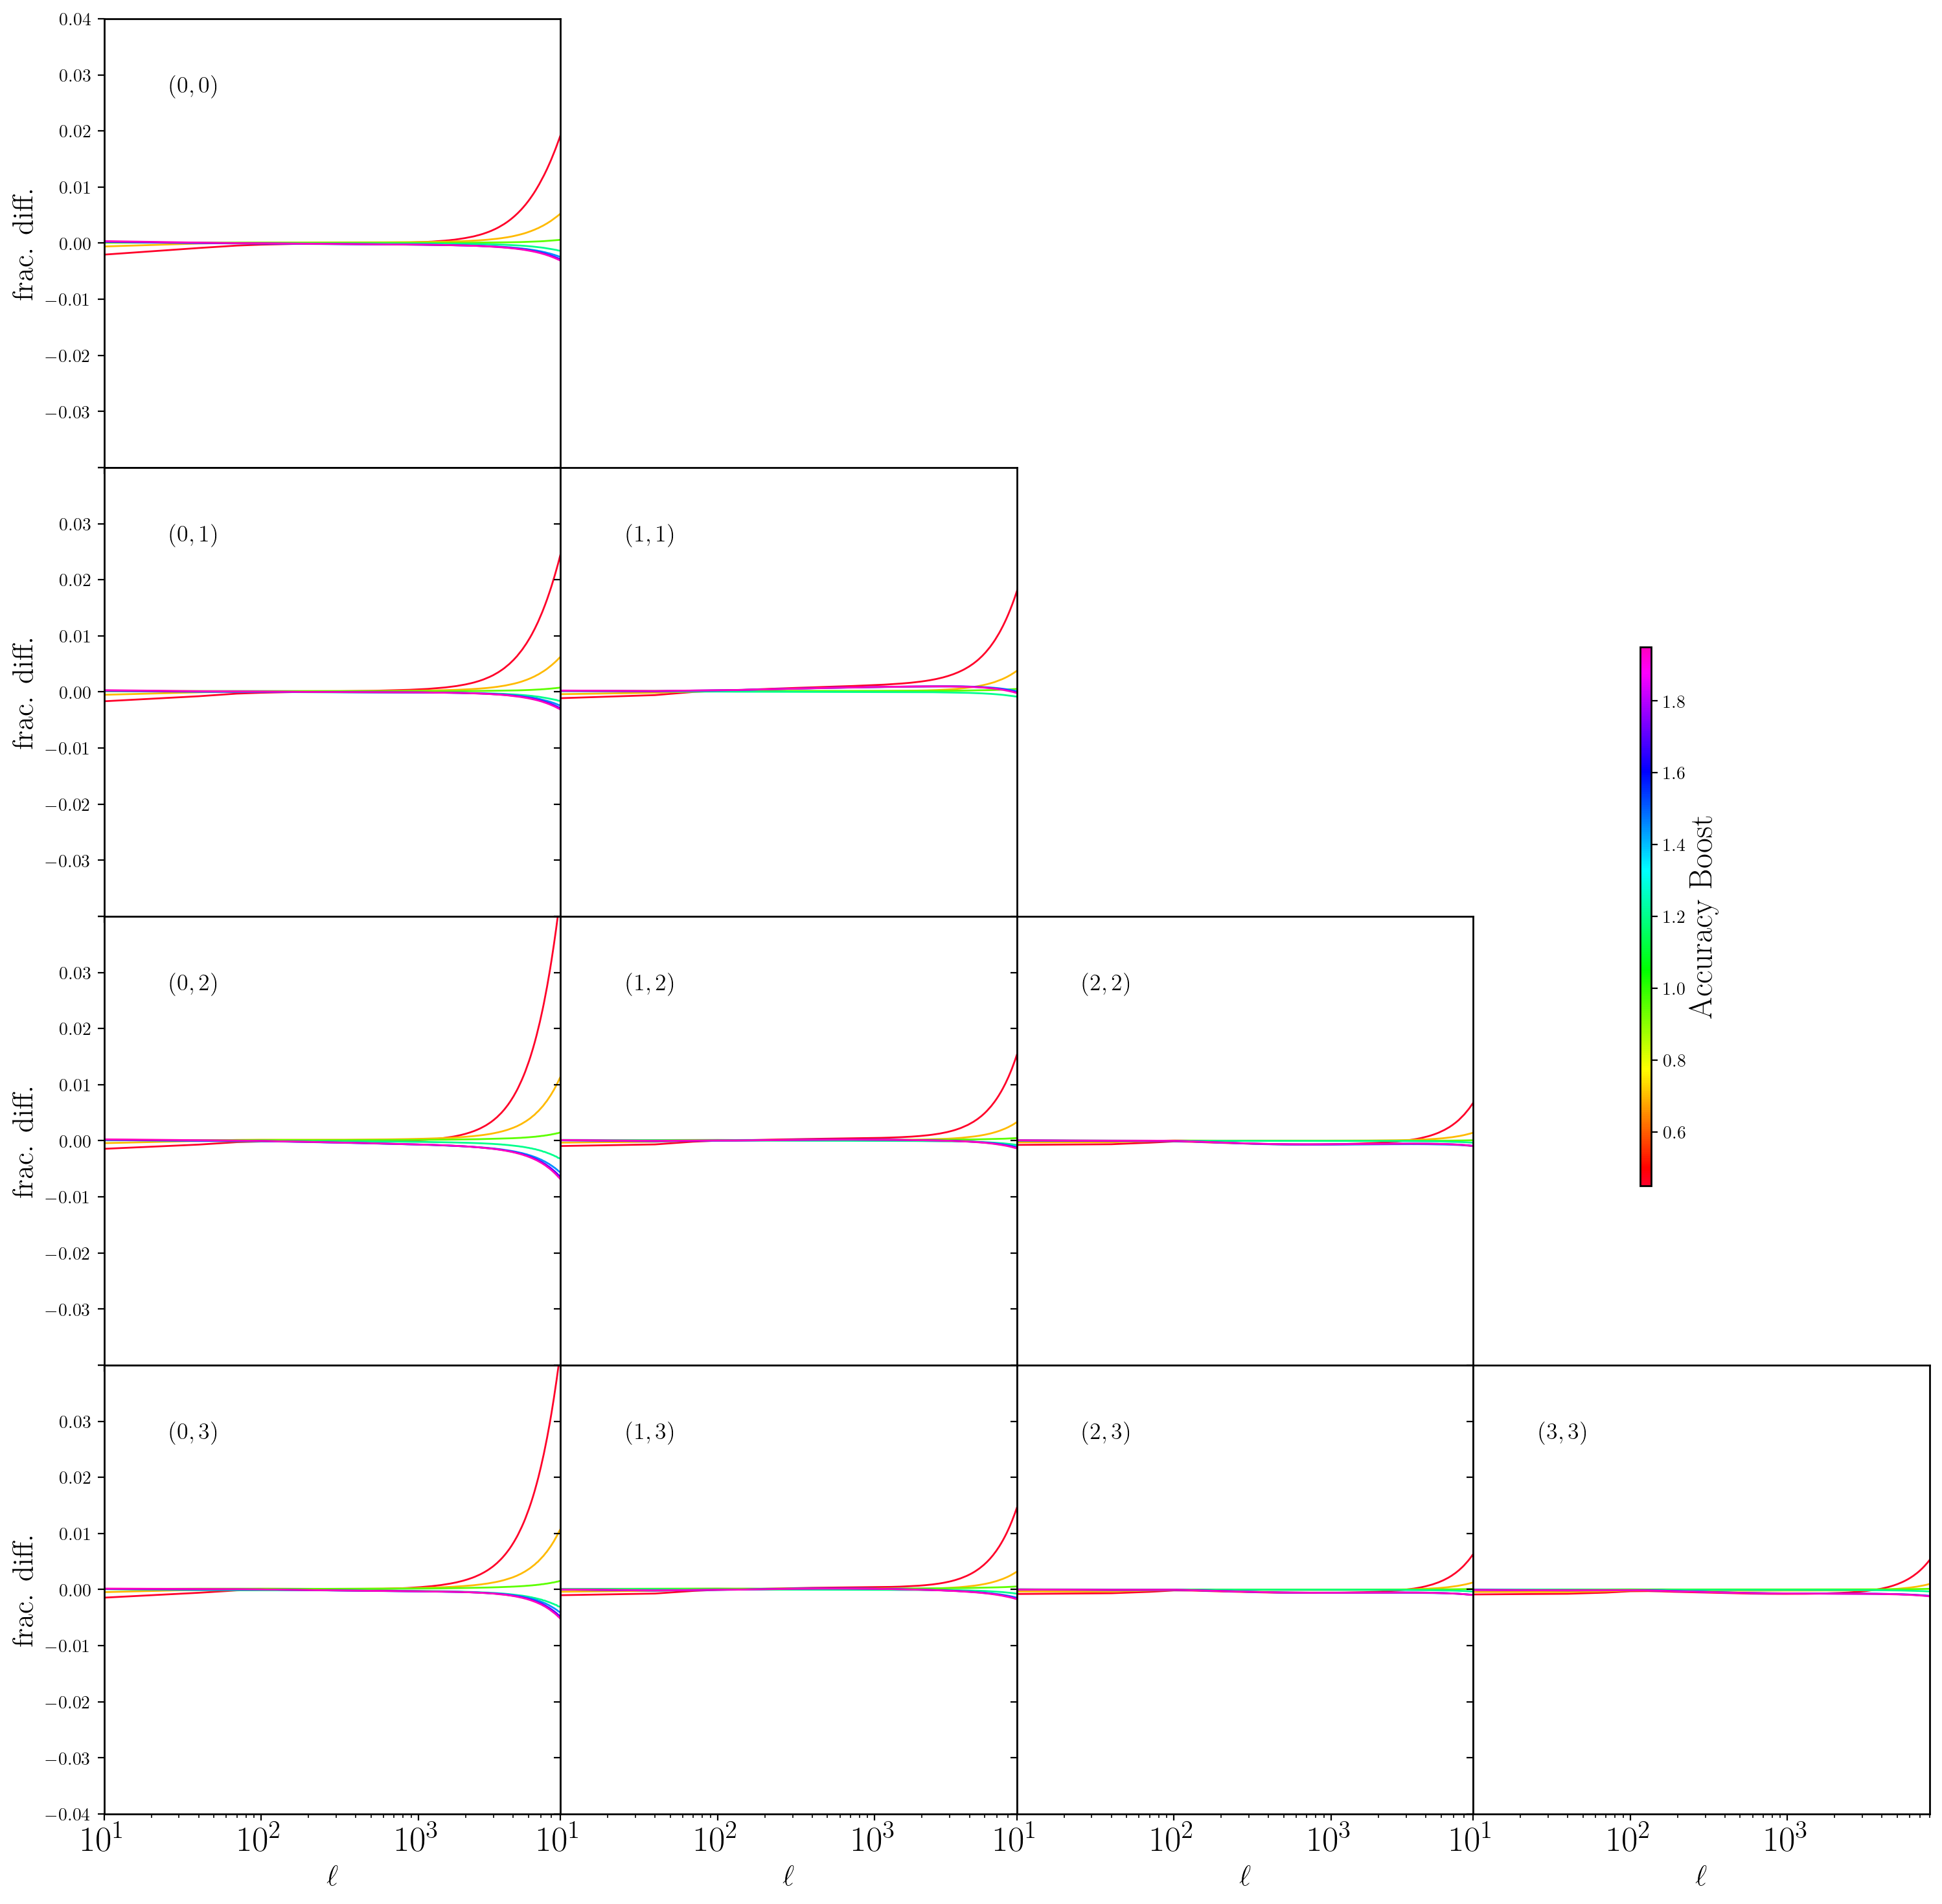

In [26]:
# ylim (0.96, 1.04): the band -4% to +4% of C/C_ref - 1
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=C_ss_ref,
                          param=param,
                          lmin=10,
                          lmax=8000,
                          ylim=(0.96,1.04),
                          colorbarlabel="Accuracy Boost")

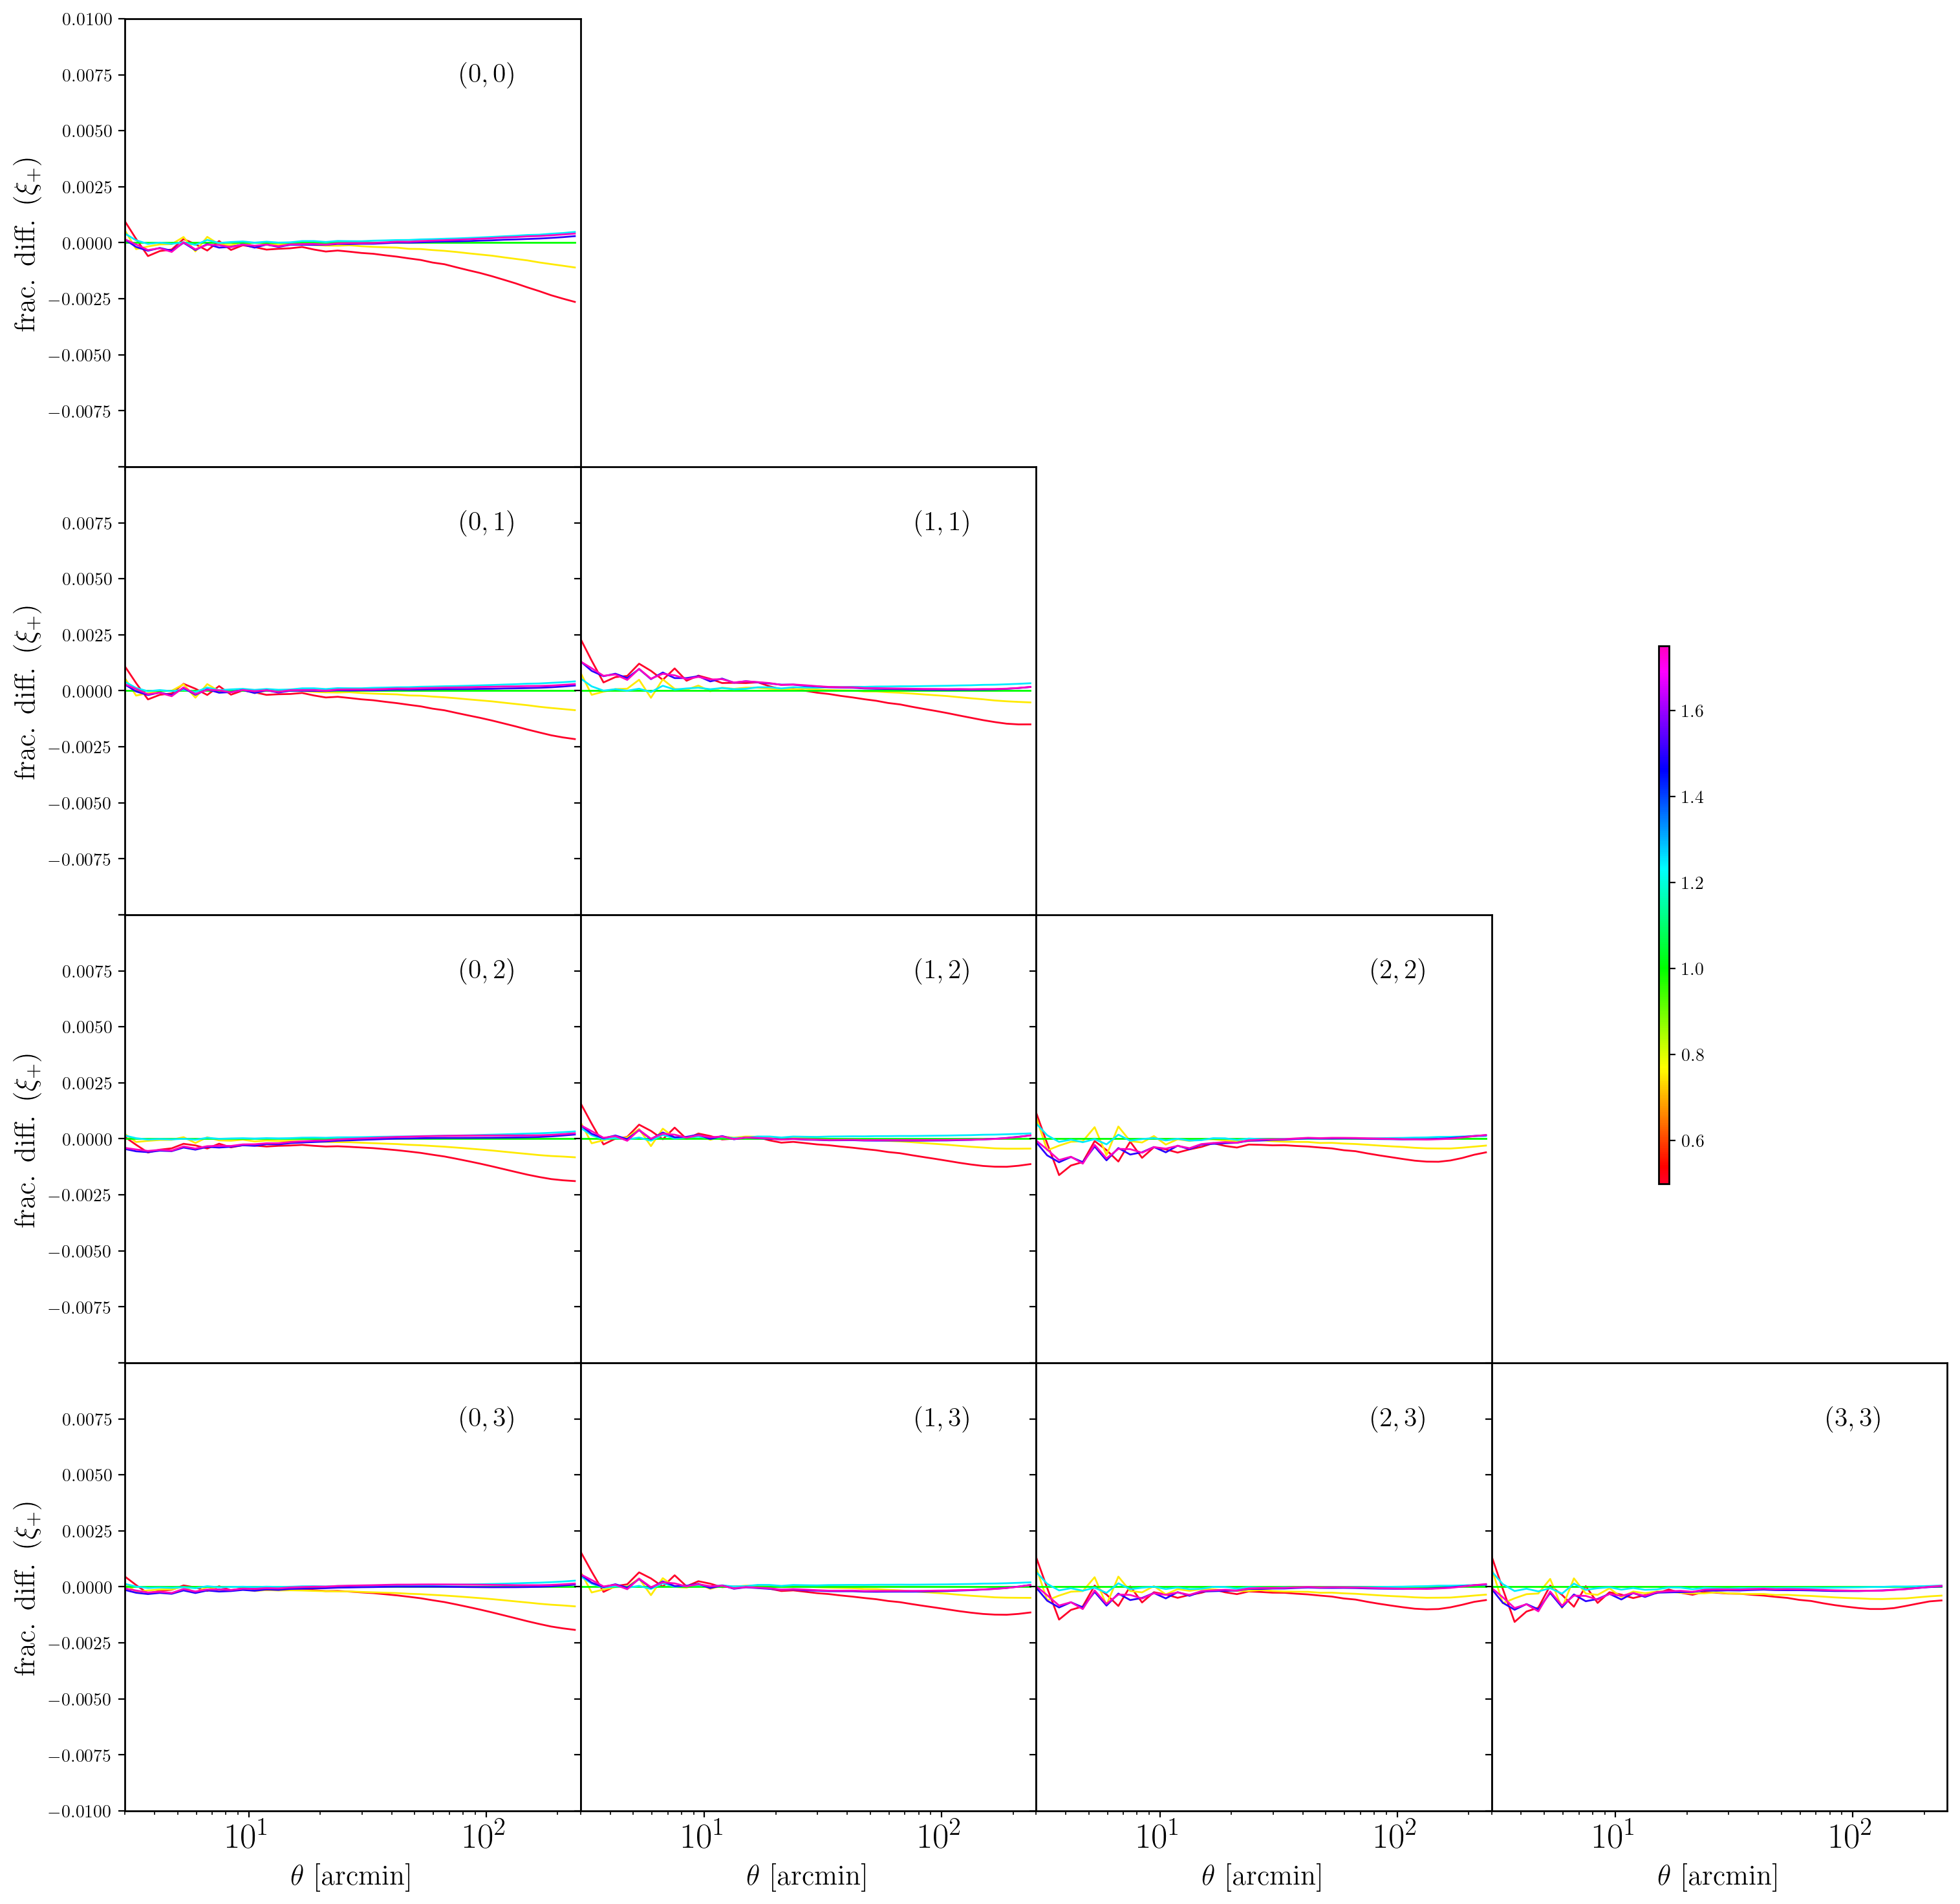

In [27]:
param = np.arange(0.5, 2.0, 0.25)
xi_theta_ref = xi(ntheta=40)

# w_theta holds xi tuples here; the name does not mean clustering w(theta)
w_theta = []
for x in param:
    w_theta.append(xi(ntheta=40, AccuracyBoost=x))
    
# ylim (0.99, 1.01): the band -1% to +1% of xi_+/xi_+ref - 1
cnu.plot_xi(pm = 1,
            xi = w_theta,
            xi_ref = xi_theta_ref,
            param=param,
            ylim=(0.99, 1.01))

## $\chi^2$ against the DES Y3 cosmic-shear data

The next cell initializes CosmoLike again, now with data. `init_probes("xi")`
selects cosmic shear: the mask of every other entry is set to zero, so 227 of the
533 baseline entries remain (166 of $\xi_+$, 61 of $\xi_-$). `init_data_real` reads
the published DES Y3 covariance, the 3×2pt baseline mask and the measured data
vector named in the dataset file.

`get_chi2` runs CAMB and the setters, then

- `compute_data_vector_masked()` returns all 900 entries of the 3×2pt layout,
  masked ones set to zero;
- `compute_chi2(t)` returns $\chi^2=(d-t)^{\mathsf T}C^{-1}(d-t)$ over the retained
  entries only, with $C^{-1}$ the inverse of the retained block of the covariance.

**Comparison with `EXAMPLE_EVALUATE1.yaml`.** The likelihood settings match that
file (TATT with power-law evolution, Halofit, quadrature level 1, `lmax` 50,000),
but two inputs differ, so the printed $\chi^2$ is not the YAML's value: this
notebook uses `DES_A2_1 = -1.79`, where the YAML sets 0.01, and `get_chi2` runs
CAMB with `kmax = 10`/Mpc, `k_per_logint = 20` and CAMB accuracy 1.1, where the
YAML uses 5, 10 and 1.0.

In [28]:
non_linear_emul = 2
CLprobe="xi"

path= "../../external_modules/data/des_y3"
data_file="des_y3_real.dataset"

IA_model = 1
IA_redshift_evolution = 3
IA_code = 0

# Init Cosmolike & data file
ini = IniFile(os.path.normpath(os.path.join(path, data_file)))

lens_file = ini.relativeFileName('nz_lens_file')
source_file = ini.relativeFileName('nz_source_file')
lens_ntomo = ini.int("lens_ntomo")
source_ntomo = ini.int("source_ntomo")

ci.initial_setup()

# initial_setup resets the FAST-PT grid fraction to the C default;
# set it again before get_chi2 calls init_accuracy_boost
ci.init_fpt_internal_boost(internal_boost = float(internal_accuracyboost))

# xi: only the cosmic-shear entries keep their mask (227 of the 533)
ci.init_probes(possible_probes = CLprobe)

ci.init_binning(int(ini.int("n_theta")), 
                ini.float("theta_min_arcmin"), 
                ini.float("theta_max_arcmin"))


ci.init_cosmo_runmode(is_linear = False)

ci.init_IA( ia_model = int(IA_model), 
            ia_redshift_evolution = int(IA_redshift_evolution),
            ia_code = int(IA_code))

ci.init_redshift_distributions_from_files(
      lens_multihisto_file=ini.relativeFileName('nz_lens_file'),
      lens_ntomo=int(ini.int("lens_ntomo")), 
      source_multihisto_file=ini.relativeFileName('nz_source_file'),
      source_ntomo=int(ini.int("source_ntomo")))

# The published DES Y3 covariance, the 3x2pt baseline mask and the
# measured data vector named in the dataset file
ci.init_data_real(ini.relativeFileName('cov_file'), 
                  ini.relativeFileName('mask_file'), 
                  ini.relativeFileName('data_file'))

def get_chi2(omegam = omegam, 
             omegab = omegab, 
             H0 = H0, 
             ns = ns, 
             As_1e9 = As_1e9, 
             w = w, 
             w0pwa = w0pwa,
             A1  = [DES_A1_1, DES_A1_2, 0, 0], 
             A2  = [DES_A2_1, DES_A2_2, 0, 0],
             BTA = [DES_BTA_1, 0, 0, 0],
             shear_photoz_bias = [DES_DZ_S1, DES_DZ_S2, DES_DZ_S3, DES_DZ_S4],
             M = [DES_M1, DES_M2, DES_M3, DES_M4],
             baryon_sims = None,
             AccuracyBoost=1.0, 
             kmax = 10, 
             k_per_logint = 20, 
             CAMBAccuracyBoost=1.1,
             CLAccuracyBoost=1.0, 
             CLIntegrationAccuracy=1):

    CLAccuracyBoost = CLAccuracyBoost * AccuracyBoost
    CLIntegrationAccuracy = max(0, CLIntegrationAccuracy + abs(3*(CLAccuracyBoost-1.0)))

    ci.init_ntable_lmax(int(50000 + 20000*(CLAccuracyBoost-1)))
    ci.init_accuracy_boost(CLAccuracyBoost, int(CLIntegrationAccuracy))
    ci.init_photoz_conventions(
        int(photoz_interpolation_type),
        int(photoz_zmid_convention))
    
    # CAMB with kmax = 10/Mpc, k_per_logint = 20 and CAMB accuracy 1.1 fixed
    # here: this call ignores the kmax, k_per_logint, CAMBAccuracyBoost and
    # AccuracyBoost arguments of get_chi2.
    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_growth, z_interp_1D, chi,
     omegan2, lnPL_cb) = cnu.get_camb_cosmology(omegam=omegam,
        omegab=omegab, H0=H0, ns=ns, As_1e9=As_1e9, w=w, w0pwa=w0pwa,
        mnu=mnu, non_linear_emul=non_linear_emul, kmax=10,
        k_per_logint=20, CAMBAccuracyBoost=1.1,
        CLAccuracyBoost=CLAccuracyBoost)
    
    ci.set_cosmology(omegam = omegam, 
                     H0 = H0, 
                     log10k_2D = log10k_interp_2D, 
                     z_2D = z_interp_2D, 
                     lnP_linear = lnPL,
                     lnP_nonlinear = lnPNL,
                     G = G_growth,
                     z_G = z_growth,
                     z_1D = z_interp_1D,
                     chi = chi,
                     omegan2 = omegan2)
    
    ci.set_nuisance_shear_calib(M = M)
    
    ci.set_nuisance_shear_photoz(bias = shear_photoz_bias)
    
    ci.set_nuisance_ia(A1 = A1, 
                       A2 = A2, 
                       B_TA = BTA)
    
    # All 900 entries, masked ones set to zero; compute_chi2 forms
    # (d - t)^T C^-1 (d - t) over the retained entries only
    datavector = np.array(ci.compute_data_vector_masked())
    return ci.compute_chi2(datavector)

In [29]:
# Not the value of EXAMPLE_EVALUATE1.yaml: DES_A2_1 and the CAMB settings
# differ (see the markdown above)
print(rf"$\chi^2$={get_chi2():3.3f}")

$\chi^2$=594.696


## Quadrature check: $\Delta\chi^2$ against the integration level

The next cell evaluates $\chi^2$ at quadrature levels 0 to 9, everything else
fixed, and subtracts the level-0 value; the plot after it shows
$\Delta\chi^2=\chi^2(\text{level})-\chi^2(0)$ against the level (the figure has no
axis labels). Each level selects a fixed Gauss–Legendre rule, a set of points
and weights for the line-of-sight integrals: for the shear spectra 96, 128,
256, 512 and 1024 points at levels 0 to 4. Higher levels reuse the 1024-point
rule, so the curve is flat beyond level 4. The project's tests treat
$|\Delta\chi^2|<0.2$ as numerically negligible.

In [30]:
param = np.arange(0, 10, 1)      
chi2 = []
for x in param:
    chi2.append(get_chi2(CLIntegrationAccuracy = x))
chi2 = np.array(chi2)
# Delta chi^2 relative to quadrature level 0
chi2 = chi2 - chi2[0]

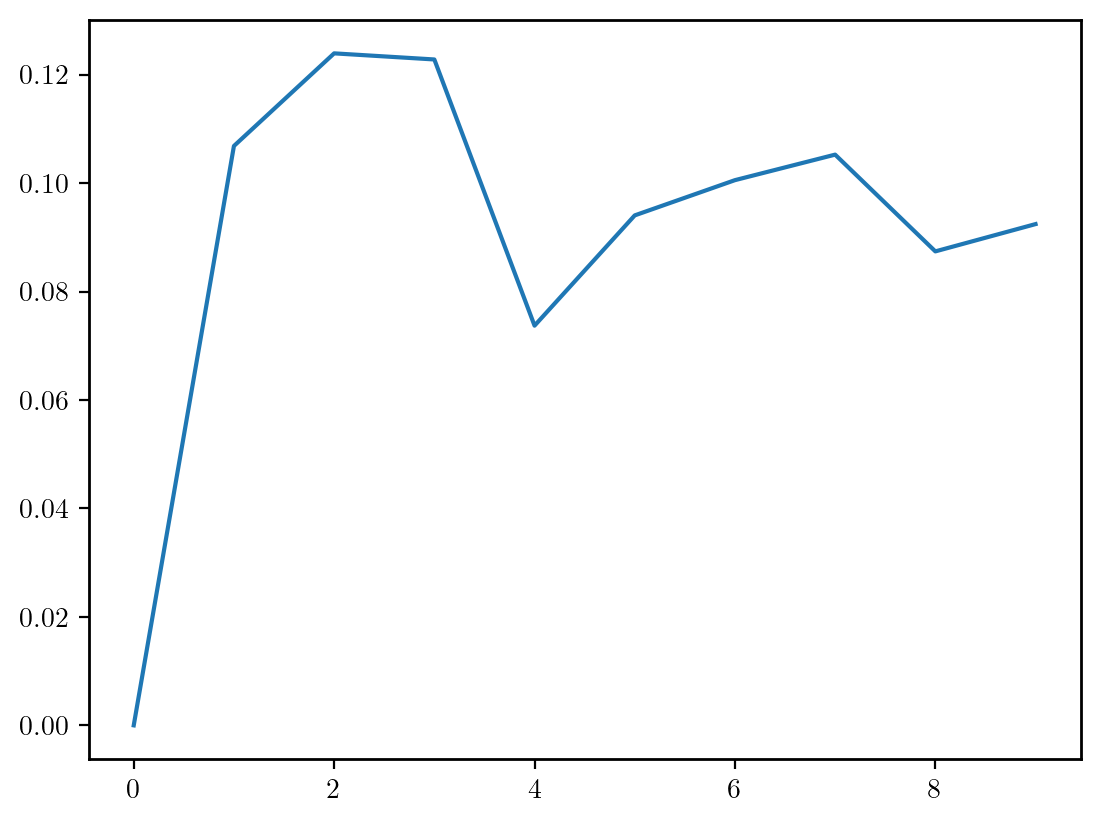

In [31]:
# Horizontal: quadrature level; vertical: Delta chi^2 (no axis labels)
plt.plot(param, np.array(chi2))

## Interpolation check: $\Delta\chi^2$ against `CLAccuracyBoost`

The next cell evaluates $\chi^2$ at `CLAccuracyBoost` = 1, 2, ..., 9 and
subtracts the boost-1 value. This boost multiplies the sizes of CosmoLike's
interpolation tables and the redshift and wavenumber grids of the CAMB tables,
and raises the multipole cutoff of `init_ntable_lmax` by 20,000 per unit;
CAMB's own accuracy stays fixed. Although the call passes
`CLIntegrationAccuracy = 1`, `get_chi2` raises the quadrature level to
$1+3(\text{boost}-1)$, so this scan refines interpolation and quadrature
together; from boost 2 on, the quadrature already uses its largest rule. The
plot has no axis labels: horizontal is the boost, vertical $\Delta\chi^2$.

In [32]:
param = np.arange(1, 10, 1)      
chi2 = []
for x in param:
    chi2.append(get_chi2(CLAccuracyBoost=x, CLIntegrationAccuracy = 1))
chi2 = np.array(chi2)
# Delta chi^2 relative to CLAccuracyBoost = 1; the quadrature level is
# 1 + 3 (boost - 1), so it rises with the boost
chi2 = chi2 - chi2[0]

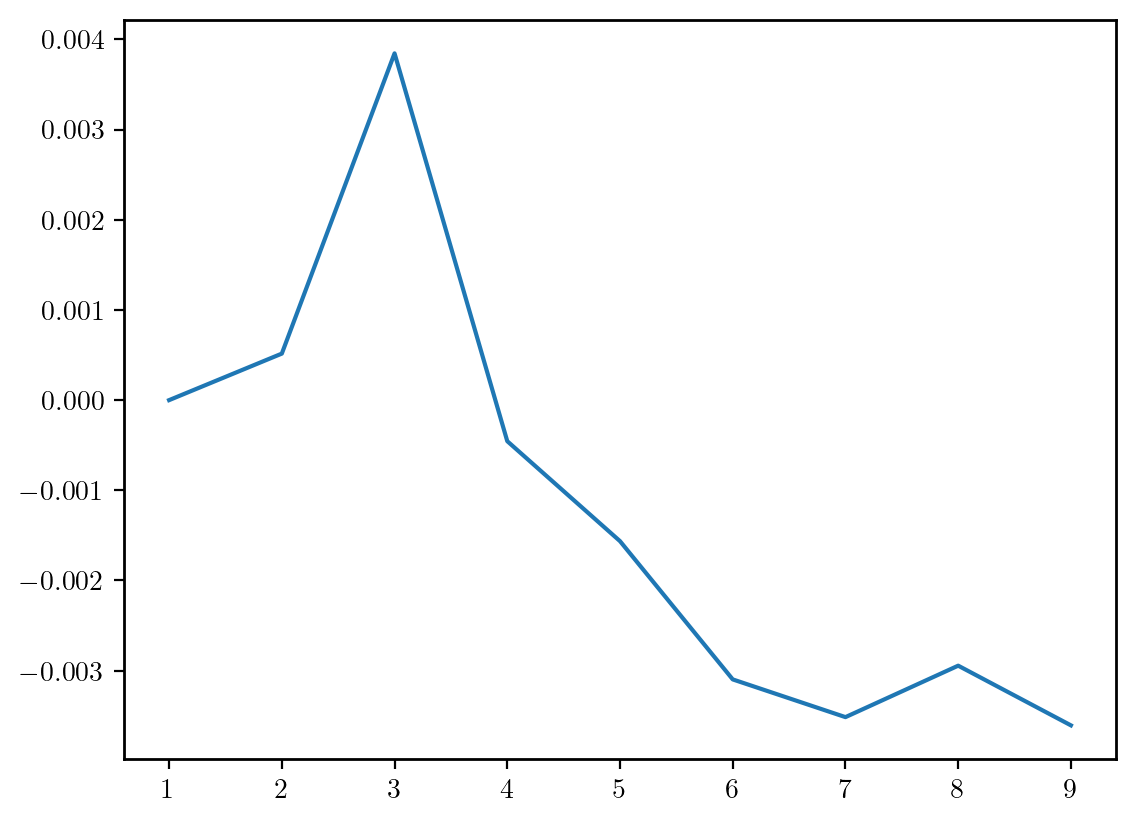

In [33]:
# Horizontal: CLAccuracyBoost; vertical: Delta chi^2 (no axis labels)
plt.plot(param, np.array(chi2))